## Chapter 7 - Applied

### Question 6

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot
import statsmodels.api as sm
from ISLP import load_data
from ISLP.models import (
    summarize,
    poly,
    ModelSpec as MS
)
from statsmodels.stats.anova import anova_lm

# New imports
from pygam import (
    s as s_gam, # smoothing spline
    l as l_gam, # linear
    f as f_gam, # factor or categorical variables
    LinearGAM,
    LogisticGAM
)
from ISLP.transforms import (
    BSpline,
    NaturalSpline
)
from ISLP.models import bs, ns
from ISLP.pygam import (
    approx_lam,
    degrees_of_freedom,
    plot as plot_gam,
    anova as anova_gam
)

# My imports
from numpy.linalg import qr
import matplotlib.pyplot as plt
import scipy
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import (
    cross_validate, 
    KFold, 
    GridSearchCV,
    train_test_split
)
from sklearn.preprocessing import StandardScaler
from IPython.display import display
from matplotlib.gridspec import GridSpec
import seaborn as sns

### Question 6

#### 6a)

In [2]:
# Load dataset
wage = pd.read_csv('data/Wage.csv')

# Check dataframe basic info
wage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   year        3000 non-null   int64  
 1   age         3000 non-null   int64  
 2   maritl      3000 non-null   object 
 3   race        3000 non-null   object 
 4   education   3000 non-null   object 
 5   region      3000 non-null   object 
 6   jobclass    3000 non-null   object 
 7   health      3000 non-null   object 
 8   health_ins  3000 non-null   object 
 9   logwage     3000 non-null   float64
 10  wage        3000 non-null   float64
dtypes: float64(2), int64(2), object(7)
memory usage: 257.9+ KB


In [3]:
# Create a function to emulate R's poly()
def poly(x, degree):
    
    # Make sure you have a column shaped data
    x = np.array(x).reshape(-1,1)

    # Create dataset as a matrix
    X = np.hstack([x**i for i in range(degree + 1)])

    # Perform QR decomposition to get orthogonal polynomials
    Q, R = qr(X, mode='reduced')

    # Adapt signals
    for i in range(Q.shape[1]):
        if R[i, i] < 0:
            Q[:, i] = -Q[:, i]

    # Fix the intercept
    Q[:, 0] = np.ones(len(Q))

    return Q

In [4]:
# Get 'y'
y = wage['wage']

# Initialize cv scores dict
cv_score_dict = {}

# Variables
k = 5
degree = 8

# Choose optimal degree for a polynomial
for i in range(degree):
    
    # Generate X matrix
    X = poly(wage['age'], i)

    # Set up k-fold cross-validation
    kfold = KFold(n_splits=k, shuffle=True, random_state=0)

    # Initialize score list
    kfold_scores = []

    # k-fold cross-validation loop
    for train_idx, val_idx in kfold.split(X):

        # Split the data
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        # Create and fit the model
        kfold_model = sm.OLS(y_train, X_train).fit()

        # Predict
        y_hat = kfold_model.predict(X_val)

        # Compute score
        mse = sum((y_val - y_hat)**2) / len(y_val)
        kfold_scores.append(mse)

    # Compute kfold & update scores list
    cv_score = np.mean(kfold_scores)
    cv_score_dict[i] = cv_score  

In [5]:
# Show results
cv_score_dict

{0: 1742.9442489767011,
 1: 1675.977977874596,
 2: 1600.6843786044096,
 3: 1597.0085553813456,
 4: 1596.2094586752364,
 5: 1598.2153075842355,
 6: 1597.237626326731,
 7: 1599.167700495703}

In [6]:
# Get the lowest mse value & its position
mse_min = min(cv_score_dict.values())
mse_min_pos = list(cv_score_dict.values()).index(mse_min)

print(f"""
The lowest mse we get is {mse_min} and is achieved by a polynomial of {mse_min_pos}th order.
""")


The lowest mse we get is 1596.2094586752364 and is achieved by a polynomial of 4th order.



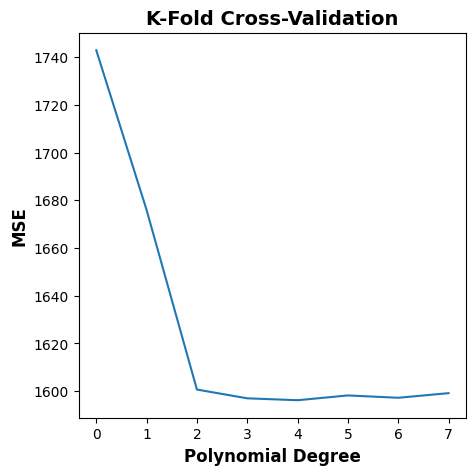

In [7]:
# Plots arguments
title_args = {
    'fontsize': 14,
    'fontweight': 'bold'
}
label_args = {
    'fontsize': 12,
    'fontweight': 'bold'
}

# Plot
plt.figure(figsize=(5,5))
plt.plot(cv_score_dict.keys(), cv_score_dict.values())
plt.title('K-Fold Cross-Validation', **title_args)
plt.xlabel('Polynomial Degree', **label_args)
plt.ylabel('MSE', **label_args);

While the results indicate that the lowest MSE is achieved with a 4th-order polynomial, the plot above reveals that increasing the polynomial degree beyond the 2nd order yields minimal improvement in MSE.

In [8]:
# Initialize models' list
models = []

# Fit models for ANOVA testing
for i in range(degree):

    # Create the polynomial matrix
    X = poly(wage['age'], i)

    # Create and fit a linear regression model
    model = sm.OLS(y, X).fit()

    # Update models' list
    models.append(model)

# ANOVA test
anova_lm(*models)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,2999.0,5.222086e+06,0.0,NaN,NaN,NaN
1,2998.0,5.022216e+06,1.0,199869.664970,125.531246,1.427311e-28
2,2997.0,4.793430e+06,1.0,228786.010128,143.692606,2.253516e-32
3,2996.0,4.777674e+06,1.0,15755.693664,9.895608,1.672982e-03
4,2995.0,4.771604e+06,1.0,6070.152124,3.812453,5.096592e-02
5,2994.0,4.770322e+06,1.0,1282.563017,0.805534,3.695162e-01
6,2993.0,4.766389e+06,1.0,3932.257665,2.469715,1.161646e-01
7,2992.0,4.763834e+06,1.0,2555.281281,1.604884,2.053110e-01


The ANOVA test provides the same results as k-fold cross-validation, we have statistical grounds to roughly support a model up to the 4th degree.

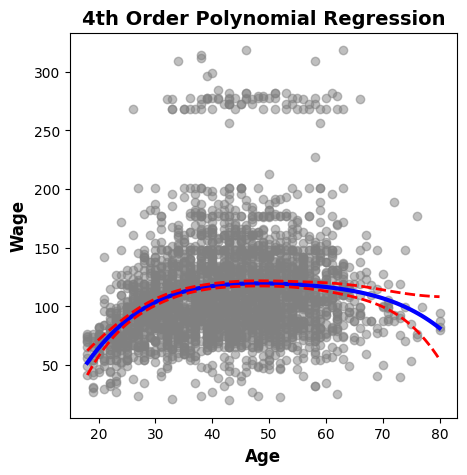

In [9]:
# Function to create a regular polynomial
def poly_regular(data, degree):   
    # Adapt the data to a column vector
    x = np.array(data).reshape(-1,1)
    # Create a matrix of polynomial
    X = np.hstack([x**i for i in range(degree + 1)])
    return X

# Get age data
age = wage['age']

# Get a grid of 100 age points
age_grid = np.linspace(age.min(), age.max(), 100)
age_df = pd.DataFrame({'age': age_grid})

# Create a 4th order features matrix
X4 = poly_regular(wage['age'], 4)
X4new = poly_regular(age_grid, 4)

# Get 'y'
y = wage['wage']

# Create and fit the model
model4 = sm.OLS(y, X4).fit()

# Predict
preds = model4.get_prediction(X4new)
# Get CI
bands = preds.conf_int(alpha=0.05)

# Plot
fig, ax = plt.subplots(figsize=(5,5))
ax.scatter(age, y, facecolor='gray', alpha=0.5)

# Plot the fitter curve and CI
ax.plot(age_df, preds.predicted_mean, 'b-', linewidth=3)
ax.plot(age_df, bands[:, 0], 'r--', linewidth=2)
ax.plot(age_df, bands[:, 1], 'r--', linewidth=2)

# Customize
ax.set_title('4th Order Polynomial Regression', **title_args)
ax.set_xlabel('Age', **label_args)
ax.set_ylabel('Wage', **label_args);

#### 6b)

In [10]:
# Age value range
age_min = age.min()
age_max = age.max()
age_range = age_max - age_min

print(f"""
Age Min:  \t{age_min}
Age Max:  \t{age_max}
Age Range:\t{age_range}
""")


Age Min:  	18
Age Max:  	80
Age Range:	62



When determining the number of splits for fitting step functions to the dataset, it is essential to consider that our age data ranges from 18 to 80 years. These splits divide the data into distinct groups, capturing variations across the age spectrum.

By look at our previous plot, it is evident that the most significant wage variation happens at the initial years after 18. This means we should have a higher number of splits on the initial years.

In [11]:
# Get data - for completeness
age = wage['age']
y = wage['wage']

# 'n' cuts
n = 15

# Number of folds
k = 5

# Create a dict to hold performance metrics
metrics = {}

# Loop through the number of splits
for i in range(1, n + 1):

    # Divide the dataset into groups & get dummies
    cut_age = pd.qcut(age, i)
    X = pd.get_dummies(cut_age)

    # Set up k-fold cross-validation
    kfold = KFold(n_splits=k, shuffle=True, random_state=0)

    # Initialize k-fold mse list
    kfold_mse = []

    # Loop through the folds
    for train_idx, val_idx in kfold.split(X):

        # Get the data splits
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        # Create & fit a model
        model = sm.OLS(y_train, X_train).fit()

        # Predict on validation set
        y_hat = model.predict(X_val)

        # Compute error
        mse = sum((y_val - y_hat)**2) / len(y_val)
        kfold_mse.append(mse)

    # Compute cross-validation mse
    cv_mse = np.mean(kfold_mse)

    # Update dict with metrics
    metrics[i] = cv_mse

In [12]:
# # Plot k-fold cross-validation results
# fig = plt.figure(figsize=(8,8))
# gs = GridSpec(1, 2, width_ratios=[2, 1])

# # Plot on the left
# ax_plot = fig.add_subplot(gs[0])
# ax_plot.plot(metrics.keys(), metrics.values())
# ax_plot.set_title('K-Fold Cross-Validation', fontsize=20)
# ax_plot.set_xlabel("Age Splits (qcut)", fontsize=16)
# ax_plot.set_ylabel('MSE', fontsize=16)

# # Table on the right
# metrics_df = pd.DataFrame(metrics.items(), columns=['Age Splits', 'MSE'])
# ax_table = fig.add_subplot(gs[1])
# ax_table.axis('tight')
# ax_table.axis('off')
# table_data = metrics_df.values
# table_cols = metrics_df.columns
# ax_table.table(cellText=table_data, colLabels=table_cols, loc='center')

# # Create a custom table
# mpl_table = ax_table.table(
#     cellText=metrics_df.values,
#     colLabels=metrics_df.columns,
#     loc='center',
#     cellLoc='center'
# )
# # Adjust table height
# mpl_table.scale(1, 2.31)

# plt.tight_layout()
# plt.show()

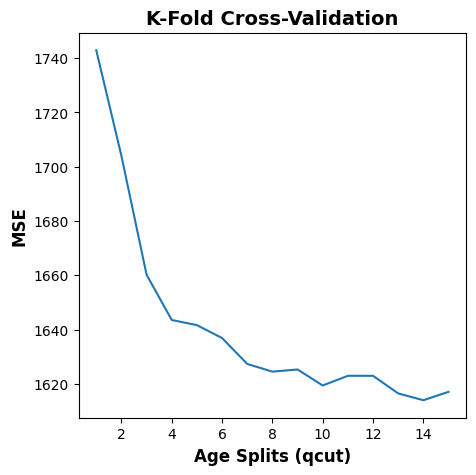

In [13]:
# Plot k-fold cross-validation
plt.figure(figsize=(5,5))
plt.plot(metrics.keys(), metrics.values())
plt.title('K-Fold Cross-Validation', **title_args)
plt.xlabel('Age Splits (qcut)', **label_args)
plt.ylabel('MSE', **label_args);

In [14]:
# Show results on a table
metrics_df = pd.DataFrame(metrics.items(), columns=['Age Splits', 'MSE'])
metrics_df.style.hide(axis='index')

Age Splits,MSE
1,1742.944249
2,1703.986248
3,1660.217470
4,1643.548938
5,1641.654152
6,1636.904085
7,1627.354737
8,1624.530608
9,1625.314705
10,1619.425203


The lowest MSE achieved through k-fold cross-validation on the age variable is 1613.99. This results was obtained using a step function with 14 splits, created with 'pd.qcut()'.

In [15]:
# Prepared data for the best results
age_split = pd.qcut(age, 14)
X = pd.get_dummies(age_split)

# Get a grid of 100 age points
age_grid = np.linspace(age.min(), age.max(), 100)
age_df = pd.DataFrame({'age': age_grid})

# Extract 
# Fit the model with best results
model = sm.OLS(y, X).fit()

# Predict
# preds = model.get_prediction(age_df)

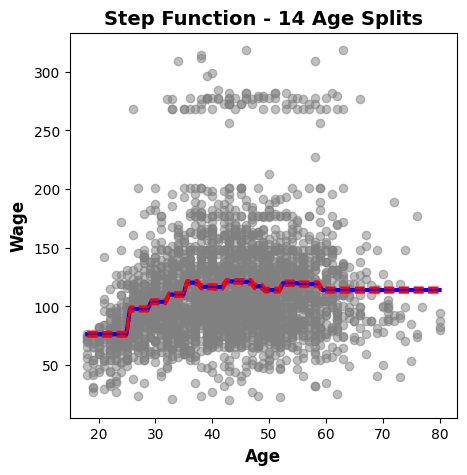

In [16]:
# Prepared data for the best results
age_split = pd.qcut(age, 14)
X = pd.get_dummies(age_split)

# Get grid with 100 age points
age_grid = np.linspace(age.min(), age.max(), 100)

# Extract bins from pd.qcut
bins = age_split.cat.categories.left.tolist() + [age_split.cat.categories.right[-1]]

# Categorize the age_grid points into the same bins
age_cut = pd.cut(age_grid, bins=bins, include_lowest=True)

# Create new dataset for prediction & plot
Xnew = pd.DataFrame(pd.get_dummies(age_cut))

# Create & fit the model with best results
model = sm.OLS(y, X).fit()

# Predict on new dataset
y_hat = model.predict(Xnew)
preds = model.get_prediction(Xnew)
# Get CI
bands = preds.conf_int(alpha=0.5)

# Plot
plt.figure(figsize=(5,5))
plt.scatter(age, y, facecolor='gray', alpha=0.5)

# Plot fitted model and CI
plt.plot(age_grid, preds.predicted_mean, '-b', linewidth=3)
plt.plot(age_grid, bands[:, 0], 'r--', linewidth=2)
plt.plot(age_grid, bands[:, 1], 'r--', linewidth=2)

# Customize
plt.title('Step Function - 14 Age Splits', **title_args)
plt.xlabel('Age', **label_args)
plt.ylabel('Wage', **label_args);

---

### Question 7


Possible non-linear techniques:

1. Poynomial
2. Splines
3. GAMs
4. Local Regression

In [17]:
# Get basic data info
wage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   year        3000 non-null   int64  
 1   age         3000 non-null   int64  
 2   maritl      3000 non-null   object 
 3   race        3000 non-null   object 
 4   education   3000 non-null   object 
 5   region      3000 non-null   object 
 6   jobclass    3000 non-null   object 
 7   health      3000 non-null   object 
 8   health_ins  3000 non-null   object 
 9   logwage     3000 non-null   float64
 10  wage        3000 non-null   float64
dtypes: float64(2), int64(2), object(7)
memory usage: 257.9+ KB


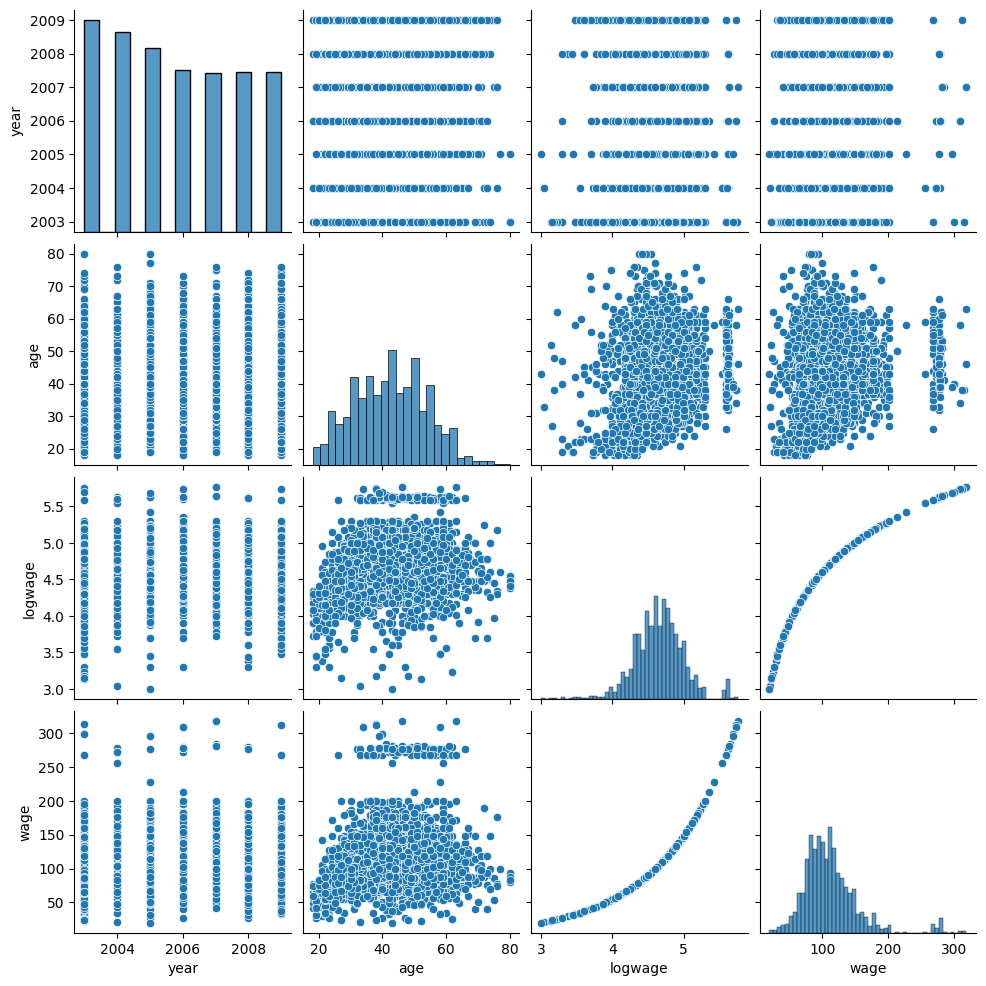

In [19]:
# Explore the dataset
sns.pairplot(wage);

The dataframe includes several columns with categorical data, which require alternative visualization techniques beyond pd.plotting.scatter_matrix().

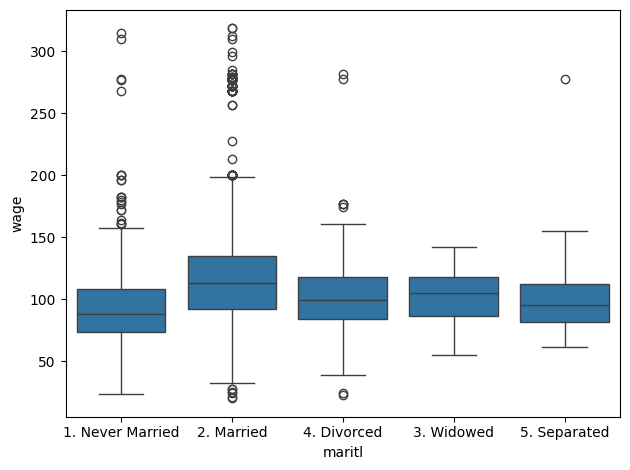

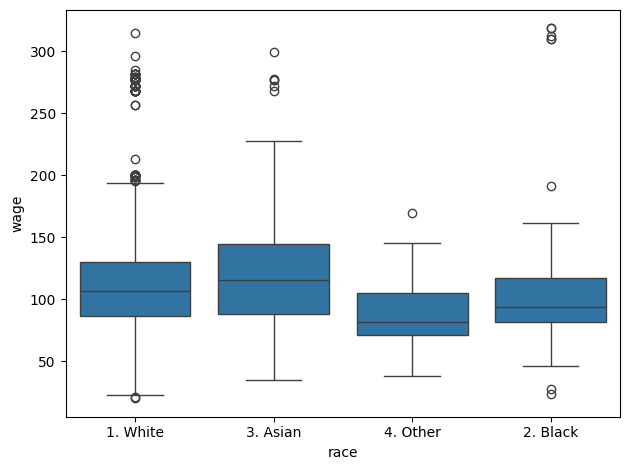

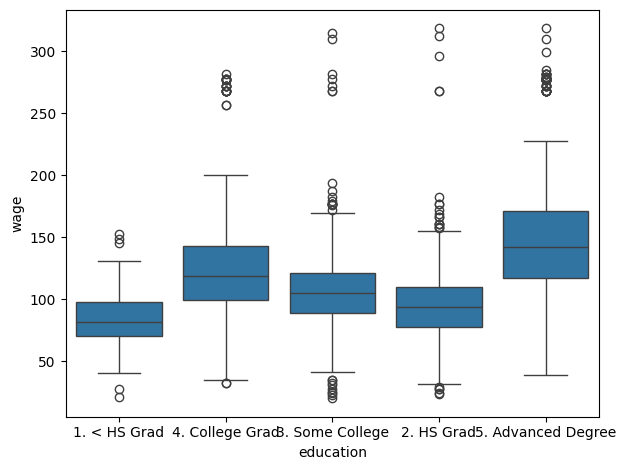

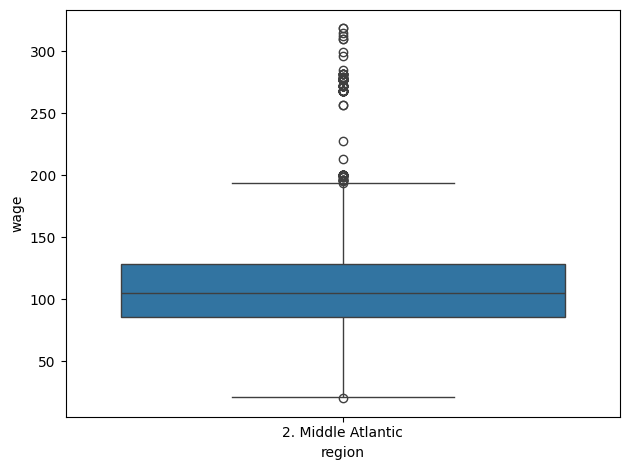

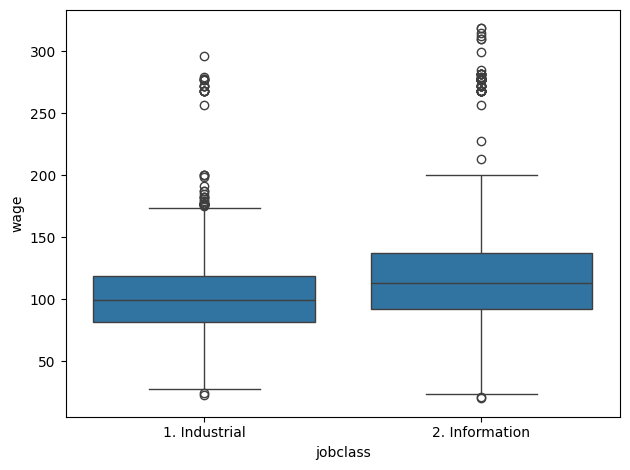

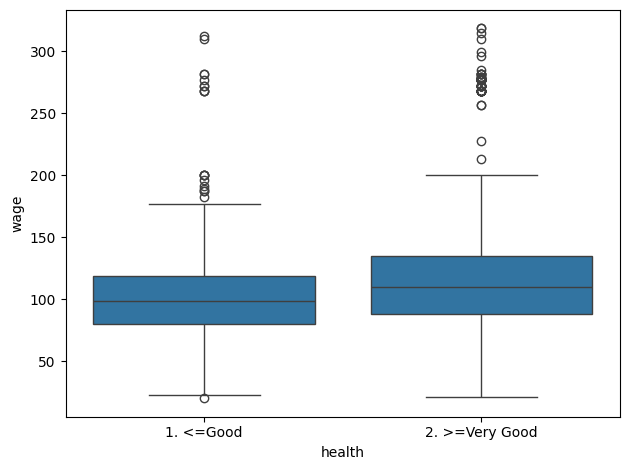

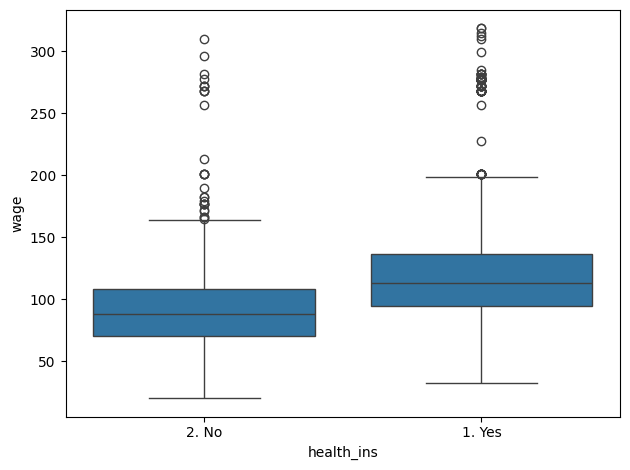

In [25]:
# List of numerical columns already ploted
numerical_cols = [
    'year',
    'age',
    'logwage',
    'wage'
]

# List the remaining cols
categorical_cols = [x for x in wage.columns if x not in numerical_cols]

# Loop through other columns
for col in categorical_cols:
    plt.figure()
    sns.boxplot(x=wage[col], y=y)
    plt.tight_layout();

The dataset has a higher number of categorical variables compared to numerical ones. A potential approach to handle this is to use GAM, applying splines to capture non-linear relationships in the numerical variables while employing linear regression for the categorical variables/dummies.

Given the uncertainty about which features to include in our GAM model, we can adopt two different strategies for model selection:

1. **GAM with Smoothness (Regularization)**: this approach applies smoothness to penalize 'wigly' splines.
2. **Forward Stepwise Selection (GAMs)**: this method adds features to the model based on their contribution on performance.

In both cases, cross-validation should be employed to validate the model selection process and confirm the chosen features.

In [26]:
# Select relevant columns
columns = [
    'year',
    'age',
    'maritl',
    'race',
    'education',
    'region',
    'jobclass',
    'health',
    'health_ins'
]

# Get data for training
y = wage['wage']
X = wage[columns].copy()

# Adapt data into 'category'
for col in X.columns[2:]:
    X[col] = X[col].astype('category')

In [27]:
# Check info to validate for 'category' data type
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   year        3000 non-null   int64   
 1   age         3000 non-null   int64   
 2   maritl      3000 non-null   category
 3   race        3000 non-null   category
 4   education   3000 non-null   category
 5   region      3000 non-null   category
 6   jobclass    3000 non-null   category
 7   health      3000 non-null   category
 8   health_ins  3000 non-null   category
dtypes: category(7), int64(2)
memory usage: 68.6 KB


In [28]:
# Set up NATURAL SPLINES
ns_age = NaturalSpline(df=4).fit(X['age'])
ns_year = NaturalSpline(df=5).fit(X['year'])

# Transform the dataset
Xs = [ns_age.transform(X['age']), ns_year.transform(X['year'])]
Xs = Xs + [pd.get_dummies(X[col]).values for col in X.columns[2:]]

# Create a matrix
X_bh = np.hstack(Xs)

# Create & fit the model
gam_bh = sm.OLS(y, X_bh).fit()

In [29]:
# Predict
y_hat = gam_bh.predict(X_bh)

# Compute MSE
mse = sum((y - y_hat)**2) / len(y)
mse

1130.0680541067643

In [30]:
# Create the GAM model
gam_full = LinearGAM(
    s_gam(0) + # smoothing spline with lam=0.6
    s_gam(1, n_splines=7) + # smoothing spline with lam=0.6
    f_gam(2, lam=0) + # categorical term without shrinkage (lam=0)
    f_gam(3, lam=0) + 
    f_gam(4, lam=0) + 
    f_gam(5, lam=0) + 
    f_gam(6, lam=0) + 
    f_gam(7, lam=0) + 
    f_gam(8, lam=0)
)

# Prepare the data
initial_cols = [X['age'], X['year']]
full_cols = initial_cols + [X[col].cat.codes for col in X.columns[2:]]
Xgam = np.column_stack(full_cols)

# Fit the model
gam_full = gam_full.fit(Xgam, y)

In [31]:
# Predict
y_hat = gam_full.predict(Xgam)

# Compute MSE
mse = sum((y - y_hat)**2) / len(y)
mse

1126.0780181974783

When using a full GAM model with all features in the dataset, applying either a **Natual Spline** or a **Smoothing Spline** produces very similar results on the training dataset. Specifically, the natural spline has an MSE of 1,130, while the smoothing spline achieves an MSE of 1,126.

It is important to be cautious when interpreting these results, as they are based solely on the training dataset. Without validation, there is a significant risk of overfitting, which could lead to overly optimistic conclusions about model performance.

To address this, we will evaluate a range of 'lam' values, which control the smoothing effect applied to the features, using k-fold cross-validation. This approach will help ensure a more robust and generalizable model selection process.

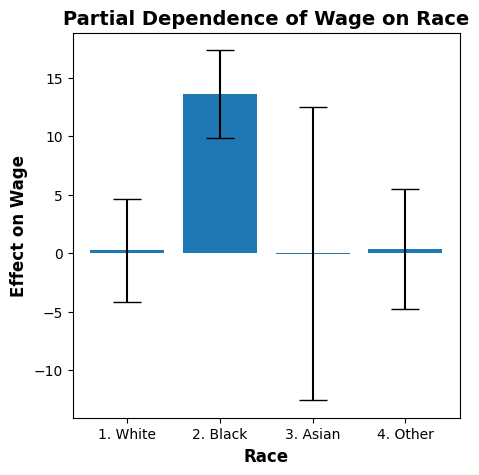

In [32]:
# Check partial dependence of 'wage' on 'race'
fig, ax = plt.subplots(figsize=(5,5))
ax = plot_gam(gam_full, 3)

# Customize
ax.set_xlabel('Race', **label_args)
ax.set_ylabel('Effect on Wage', **label_args)
ax.set_title('Partial Dependence of Wage on Race', **title_args)
ax.set_xticklabels(X['race'].cat.categories, fontsize=10);

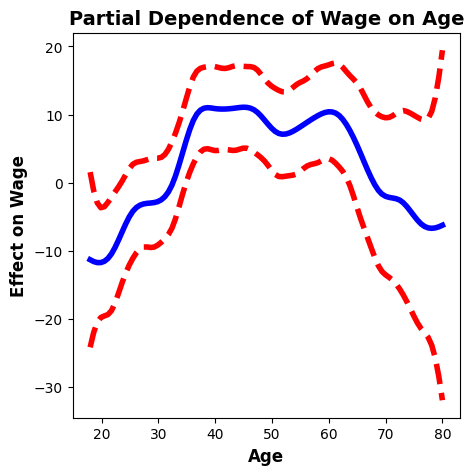

In [33]:
# Plot
fig, ax = plt.subplots(figsize=(5,5))
ax = plot_gam(gam_full, 0)

# Customize
ax.set_xlabel('Age', **label_args)
ax.set_ylabel('Effect on Wage', **label_args)
ax.set_title('Partial Dependence of Wage on Age', **title_args);

In [34]:
gam_full.lam

[[0.6], [0.6], [0], [0], [0], [0], [0], [0], [0]]

In [35]:
# Set up k-fold cross-validation
k = 5
kfold = KFold(n_splits=k, shuffle=True, random_state=0)

# Get a range of lam values to test
lam = np.logspace(-2, 5, 3)

# Fixed values for the first two variables
fixed_lams = [0.6, 0.6]

# Assign the range of lam values to the remaining coefficients
lams = fixed_lams + [lam] * 7

In [ ]:
# Perform the grid search
gam_full.gridsearch(Xgam, y, lam=lams)

In [37]:
# Show best lam parameters
gam_full.lam

[[0.6],
 [0.6],
 [31.622776601683796],
 [100000.0],
 [0.01],
 [0.01],
 [31.622776601683796],
 [31.622776601683796],
 [0.01]]

The grid search results show us a quite high regularization value of 100,000 for 'race' paramenter, indicating that the model is strongly penalizing complexity in this feature. This high regularization suggests that the relationship between 'race' and 'wage' might be relatively simple.

In [38]:
# Predict
y_hat = gam_full.predict(Xgam)

# Compute MSE
mse = sum((y - y_hat)**2) / len(y)
print(f'MSE: {mse}')

MSE: 1128.577047555474


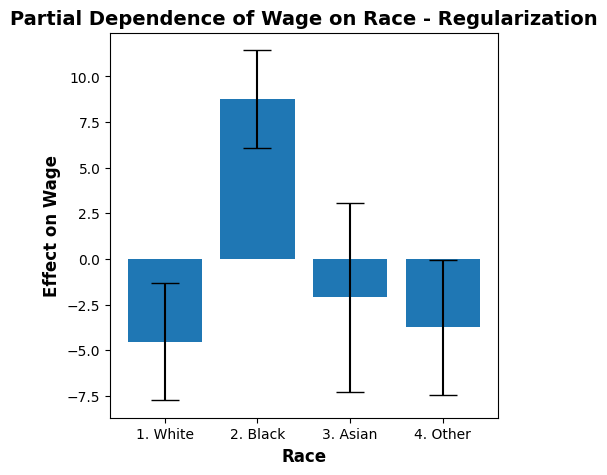

In [39]:
# Plot
fig, ax = plt.subplots(figsize=(5,5))
ax = plot_gam(gam_full, 3)

# Customize
ax.set_xlabel('Race', **label_args)
ax.set_ylabel('Effect on Wage', **label_args)
ax.set_title('Partial Dependence of Wage on Race - Regularization', **title_args)
ax.set_xticklabels(X['race'].cat.categories, fontsize=10);

After applying a strong smoothness parameter to the 'race' feature, the model appears beeter equipped to capture meaningful patterns and relationships between 'race' and 'wage'. It allows to extract more relevant information from the categorical variable, when comparing to the previous partial dependence plot without the smoothness parameter.

This improvement highlights the importance of appropriately tuning regularization parameters in GAMs.

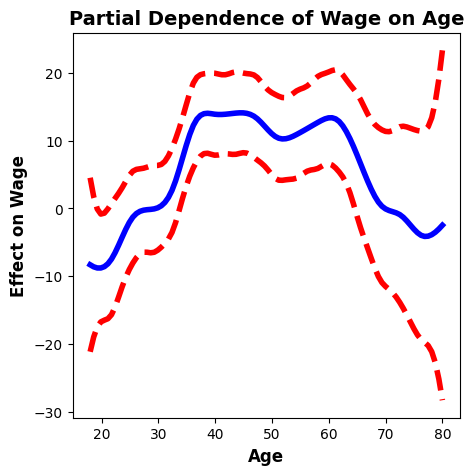

In [40]:
# Plot
fig, ax = plt.subplots(figsize=(5,5))
ax = plot_gam(gam_full, 0)

# Customize
ax.set_xlabel('Age', **label_args)
ax.set_ylabel('Effect on Wage', **label_args)
ax.set_title('Partial Dependence of Wage on Age', **title_args);

When comparing the partial effects from the models with and without regularization, some notable differences emerge.

The partial dependence of 'wage' on 'age' remains the same between the two models because both share a fixed regularization parameter 'lam' of 0.6 for this feature. However, when examining the partial dependence of 'wage' on 'race', the regularized model captures more nuanced patterns across different racial groups.

In contrast, the model without regularization provides minimal information regarding the relationship between 'wage' and 'race'. The second model, with a substantial regularization parameter 'lam' of 1000 for 'race', highlights these differences more effectively.

The regularized mode has an MSE of 1128, slightly higher than the MSE of 1126 for the unregularized model. However, this difference is insufficient to concluse that one model is superior to the toher without further validation on a hold-out dataset. Testing on unseen data is critical to ensure the generalizability and robustness of these models.

---

### Question 8

In [41]:
# Load the dataset
auto = pd.read_csv('data/Auto.csv')

In [42]:
# Get simple info
auto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           397 non-null    float64
 1   cylinders     397 non-null    int64  
 2   displacement  397 non-null    float64
 3   horsepower    397 non-null    object 
 4   weight        397 non-null    int64  
 5   acceleration  397 non-null    float64
 6   year          397 non-null    int64  
 7   origin        397 non-null    int64  
 8   name          397 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.0+ KB


The columns 'horsepower' and 'name' are 'object' data type. While it makes sense for 'name' to be an object, it seems unsual for 'horsepower' to have this data type. This discrepancy suggests that there may be non-numeric or missing values in the 'horsepowwer' column.

After some exploration, it is possible to notice '?' in the dataframe. We should exclude such observations to avoid further problems.

In [43]:
# Replace '?' with NaN
auto.replace('?', np.nan, inplace=True)

# Drop rows with NaN values
auto.dropna(inplace=True)

# Reset index
auto.reset_index(drop=True, inplace=True)

# Adapt 'horsepower' to float
auto['horsepower'] = auto['horsepower'].astype(float)

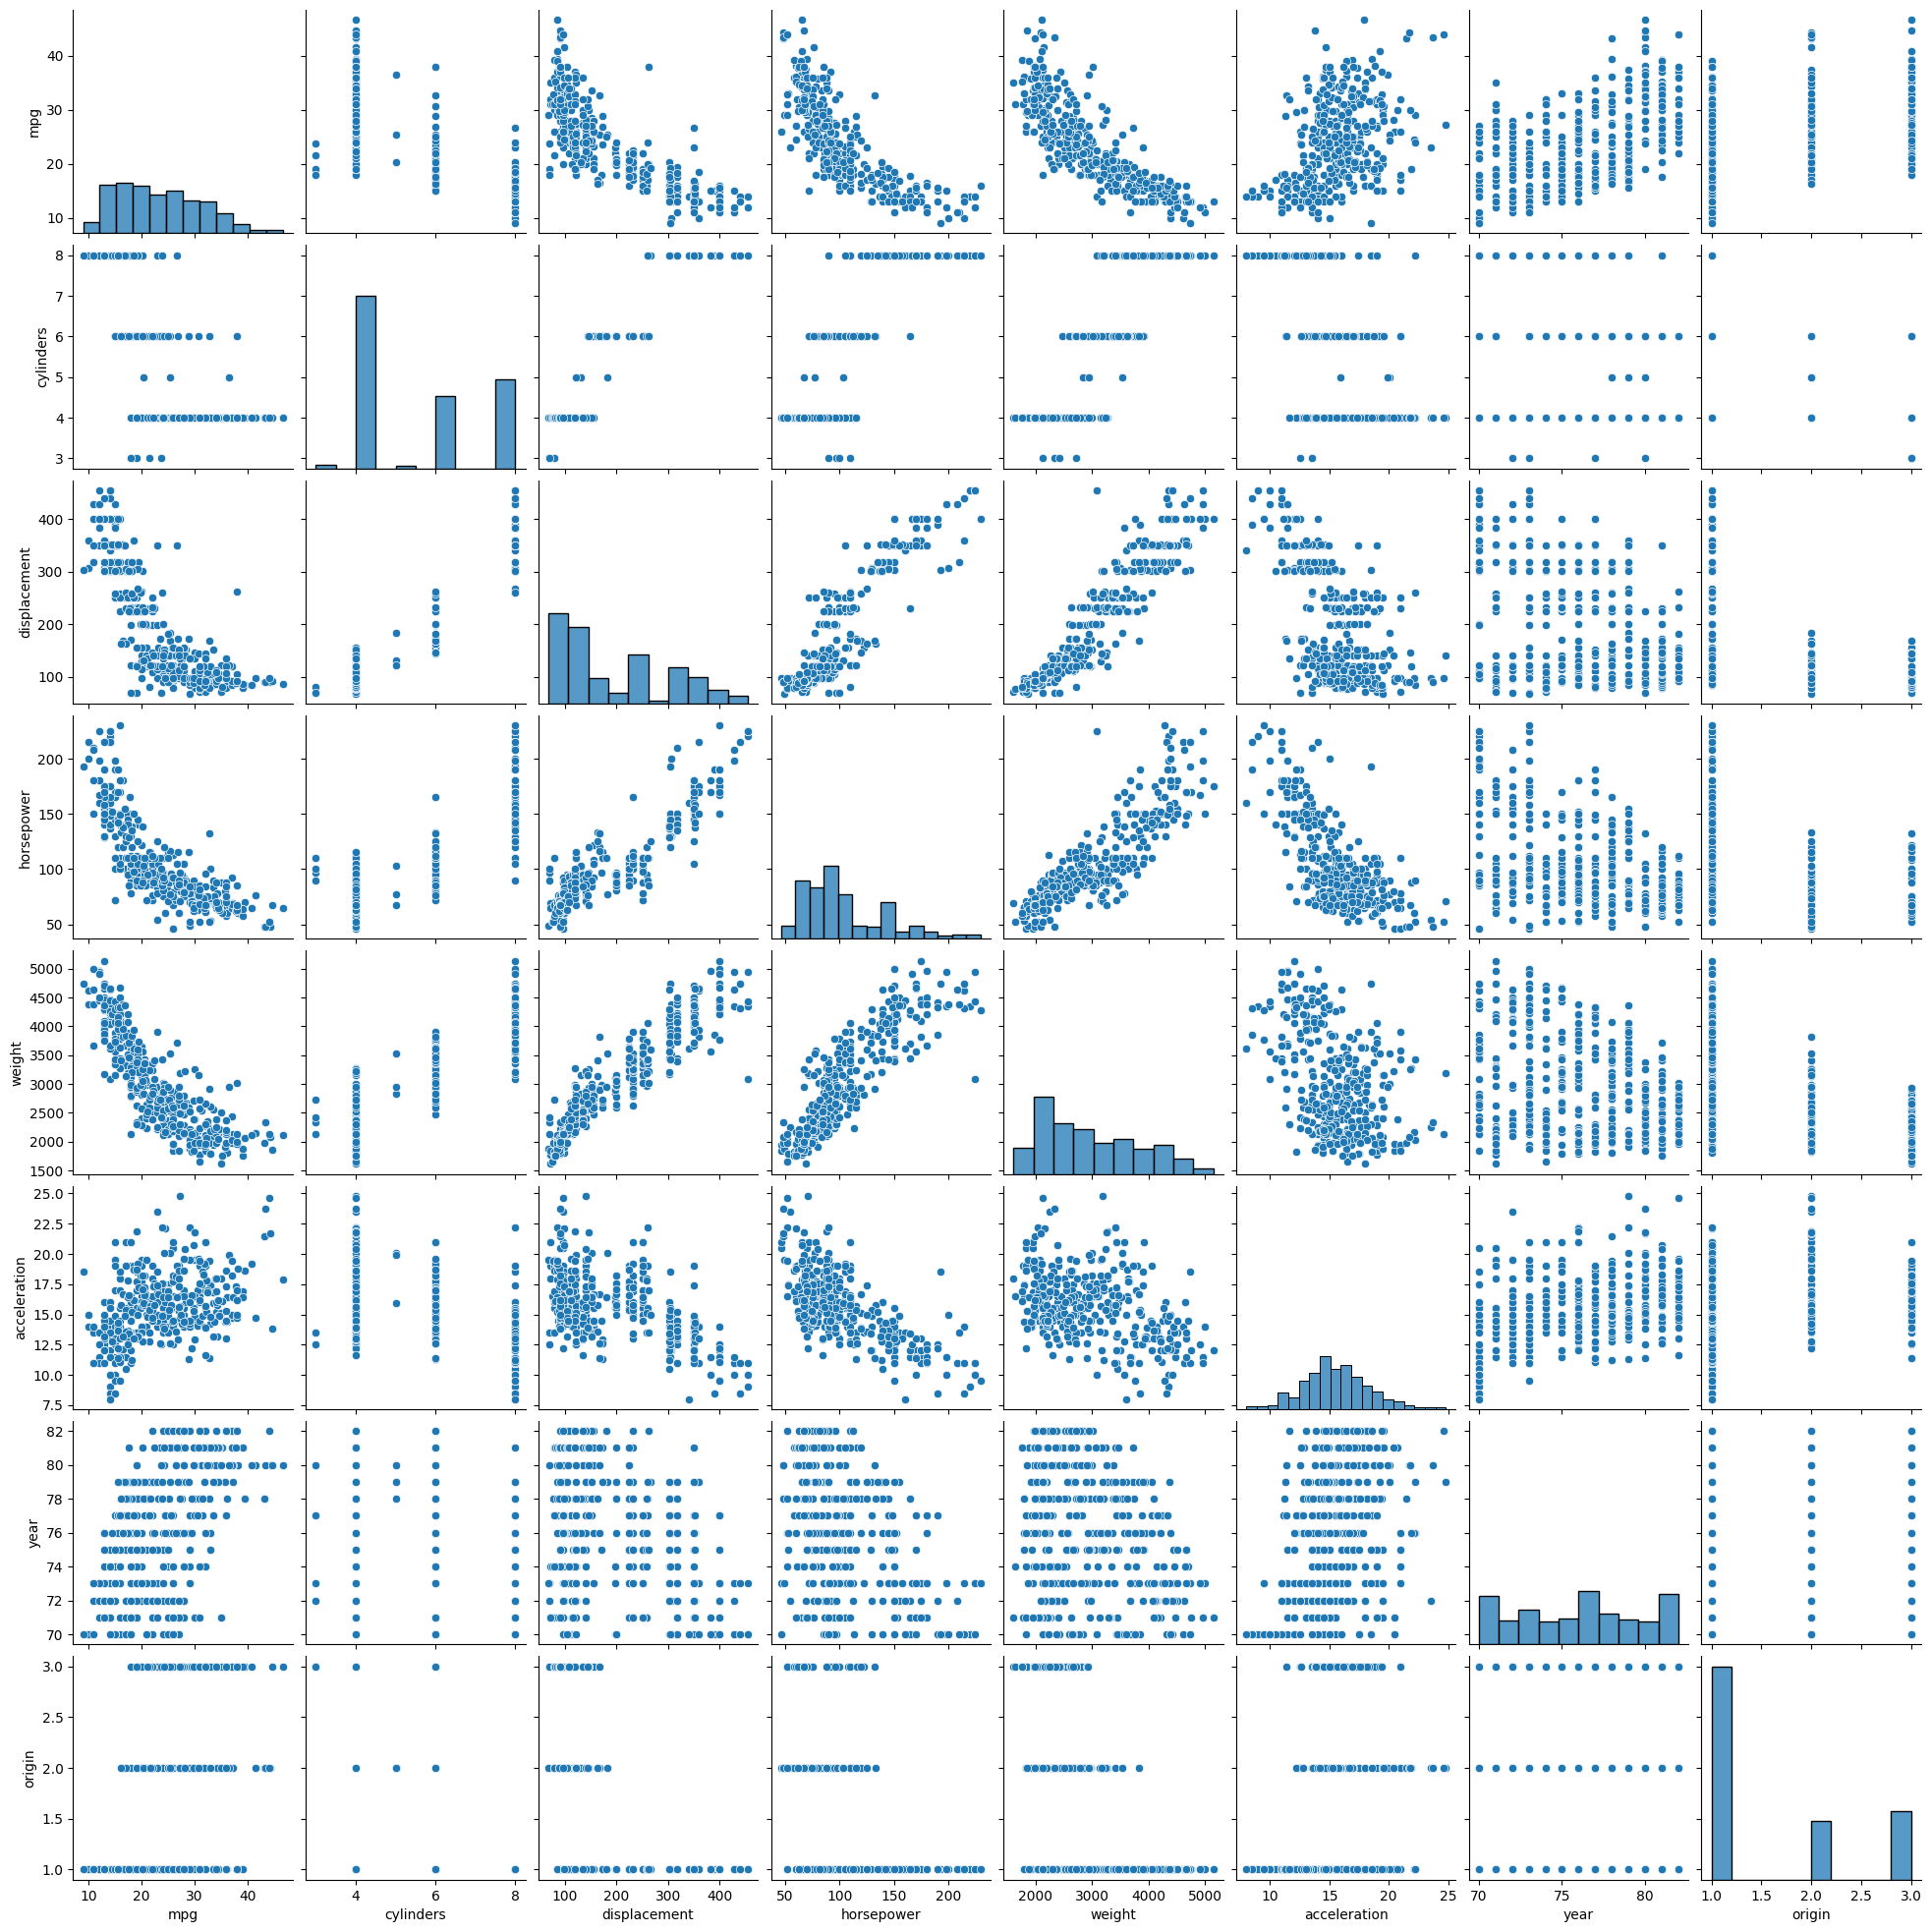

In [44]:
# Try finding initial & visual patterns
sns.pairplot(auto);

The 'Auto' dataset seems to hold more noticeable relationships and patterns among its features upon an initial inspection, as observed in the scatter matrix plot.

Notably, some non-linear relationships are evident upon initial inspection. For instance, the plots of 'displacement' vs 'mpg', 'weight' vs 'mpg' and 'horsepower' vs 'mpg' reveal a degree of curvature, suggesting that these relationships may not follow a simple linear trend.

In [45]:
# Split the data before training/fitting a model
y = auto['mpg']
X = auto.drop('mpg', axis=1)
hp = X['horsepower']

In [46]:
# Add intercept to dataset
X_linear = pd.DataFrame({'intercept': np.ones(len(hp)), 'horsepower':hp})

# Fit a linear regression 
model_linear = sm.OLS(y, X_linear).fit()

# Compute MSE
y_hat_linear = model_linear.predict(X_linear)
mse_linear = sum((y - y_hat_linear)**2) / len(y)
round(mse_linear, 2)

23.94

When fitting a linear regression model to the data, we get an MSE of 23.94.

In [47]:
# Set up k-fold cross-validation method
kfold = KFold(n_splits=n, shuffle=True, random_state=0)

# Create a dict to hold results
cv_poly_dict = {}

# List to hold models for ANOVA testing
models_list = []

# Loop through degrees
for i in range(1, 11):
    # Create a polynomial dataset
    X_poly = poly_regular(hp, i)

    # Fit a model & update models_list
    model = sm.OLS(y, X_poly).fit()
    models_list.append(model)

    # Initialize kfold_results list
    kfold_results = []
    
    # Loop through cv splits
    for train_idx, val_idx in kfold.split(X_poly):
        X_train, X_val = X_poly[train_idx], X_poly[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        # Create & train a model on train dataset
        model = sm.OLS(y_train, X_train).fit()

        # Compute MSE on val dataset
        y_hat = model.predict(X_val)
        mse = sum((y_val - y_hat)**2) / len(y_val)

        # Update results
        kfold_results.append(mse)

    # Compute cv MSE & update dict
    mse_cv = round(np.mean(kfold_results), 2)
    cv_poly_dict[i] = mse_cv
        
# Show results
cv_poly_dict

{1: 24.18,
 2: 19.12,
 3: 19.2,
 4: 19.32,
 5: 18.99,
 6: 18.94,
 7: 18.94,
 8: 23.11,
 9: 38.6,
 10: 75.28}

In [48]:
# Perform ANOVA test
anova_lm(*models_list)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,390.0,9385.915872,0.0,NaN,NaN,NaN
1,389.0,7442.029412,1.0,1943.886460,29.990522,7.805491e-08
2,388.0,7426.436007,1.0,15.593405,0.240577,6.240670e-01
3,387.0,7399.522632,1.0,26.913375,0.415223,5.197121e-01
4,386.0,7223.371686,1.0,176.150946,2.717679,1.000559e-01
5,386.0,7246.195595,-0.0,-22.823909,inf,NaN
6,386.0,7241.391853,-0.0,4.803742,-inf,NaN
7,386.0,8594.571103,-0.0,-1353.179249,inf,NaN
8,386.0,13700.161251,-0.0,-5105.590148,inf,NaN
9,387.0,25084.060097,-1.0,-11383.898846,175.632208,NaN


When performing k-fold cross-validation over a range of polynomial degrees, we observe minimal improvement in performance beyond the 2nd degree, extending up to the 7th. Given this negligible difference, we will select the 5th-degree polynomial model for our analysis. This choice balances complexity and performance, as the 7th-degree model offers only marginally better accuracy.

As seen on the ANOVA results, we only get validation of improvement in model performance with the 2nd degree polynomial.

In [49]:
# Create a 5th-degree dataset
X_poly = poly_regular(hp, 5)

# Create and fit the polynomial model
model_poly = sm.OLS(y, X_poly).fit()

# Predict & compute MSE
y_hat_poly = model_poly.predict(X_poly)
mse_poly = sum((y - y_hat_poly)**2) / len(y)

In [50]:
# Create a GAM smoothing model
gam_smoothing = LinearGAM(
    s_gam(0)
)

# Fit the model
gam_smoothing = gam_smoothing.fit(hp, y)

# Predict and compute MSE
y_hat_gam = gam_smoothing.predict(hp)
mse_gam = sum((y - y_hat_gam)**2) / len(y)

In [51]:
# Create a GAM smoothing model
gam_smoothing2 = LinearGAM(
    s_gam(0)
)

# Fit the model
gam_smoothing2 = gam_smoothing.fit(hp, y)

# Create a range of 'lam' values to test
lam = np.logspace(-2, 5, 10)

# Perform the gridsearch
gam_smoothing2.gridsearch(hp, y, lam=lam)

  0% (0 of 10) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
100% (10 of 10) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


LinearGAM(callbacks=[Deviance(), Diffs()], fit_intercept=True, 
   max_iter=100, scale=None, terms=s(0) + intercept, tol=0.0001, 
   verbose=False)

In [52]:
# Show the best 'lam' value
gam_smoothing2.lam

[[12.91549665014884]]

In [53]:
# Compute MSE
y_hat_gam2 = gam_smoothing2.predict(hp)
mse_gam2 = sum((y - y_hat_gam2)**2) / len(y)

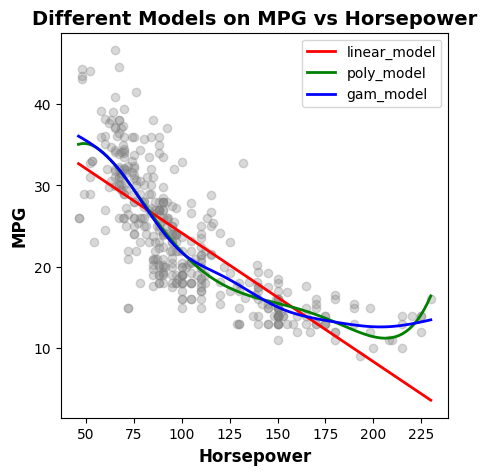

In [54]:
# Create a range of 'horsepower' observations
hp_grid = np.linspace(hp.min(), hp.max(), 100)
hp_grid_linear = np.column_stack((np.ones(len(hp_grid)), hp_grid))
hp_grid_poly = poly_regular(hp_grid, 5)

# Predict on the dataset
preds_linear = model_linear.predict(hp_grid_linear)
preds_poly = model_poly.predict(hp_grid_poly)
preds_gam2 = gam_smoothing2.predict(hp_grid)

# Plot
fig, ax = plt.subplots(figsize=(5,5))
ax.scatter(hp, y, facecolor='gray', alpha=0.3)
ax.plot(hp_grid, preds_linear, linewidth=2, c='red', label='linear_model')
ax.plot(hp_grid, preds_poly, linewidth=2, c='green', label='poly_model')
ax.plot(hp_grid, preds_gam2, linewidth=2, c='blue', label='gam_model')

# Customize
ax.set_title('Different Models on MPG vs Horsepower', **title_args)
ax.set_xlabel('Horsepower', **label_args)
ax.set_ylabel('MPG', **label_args)
ax.legend();

In [55]:
# Create a dataframe for models' MSE
results = pd.DataFrame(columns=['Model', 'MSE'])
results.loc[len(results)] = 'linear_model', round(mse_linear,2)
results.loc[len(results)] = 'poly_model', round(mse_poly, 2)
results.loc[len(results)] = 'gam_model', round(mse_gam2, 2)

# Show dataframe without the index
results.style.hide(axis='index')

Model,MSE
linear_model,23.940000
poly_model,18.430000
gam_model,18.210000


We can notice a non-linear relationship between 'mpg' and 'horsepower'. When evaluating different models, it becomes evident that a linear model cannot adequately capture the true underlying pattern in the data. On the other hand, a 5th-degree polynomial model does capture the non-linearity but seems to introduce excessive wiggles, suggesting overfitting. The smoothing GAM model provides a more accurate and balanced representation of the non-linear relationship, effectively capturing the pattern. This is reinforced by the MSE values presented in the table above.

---

### Question 9

#### 9a), b), c)

In [56]:
# Import dataset
boston = pd.read_csv('data/Boston.csv')

# Drop the first column
boston = boston.iloc[:, 1:]

# Quick info
boston.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  lstat    506 non-null    float64
 12  medv     506 non-null    float64
dtypes: float64(10), int64(3)
memory usage: 51.5 KB


In [57]:
# Split the data for training
nox = boston['nox']
dis = boston['dis']

# Use standardized variables
y = nox
X = dis

In [58]:
# Variables
d = 11
k = 5

# Set up a k-fold cross-validation method
kfold = KFold(n_splits=k, shuffle=True, random_state=0)

# Create a results dict
results_dict = {}

# Initialize a models list
models_list = []

# Create a models summary dataframe
models_df = pd.DataFrame(columns=['Degree', 'RSS', 'RSS-CV'])

# Loop through the degrees
for i in range(1, d):
    
    # Create a polynomial dataset
    X = poly_regular(dis, i)

    # Initialize results list
    rss_list = []
    mse_list = []

    # Loop through splits
    for train_idx, val_idx in kfold.split(X):

        # get the splits of data
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        # Create & fit the model
        model = sm.OLS(y_train, X_train).fit()

        # Predict on validation set
        y_hat = model.predict(X_val)
        rss = sum((y_val - y_hat)**2)
        mse = rss / len(y_val)

        # Update results
        rss_list.append(rss)
        mse_list.append(mse)

    # Compute cross-validation RSS & MSE
    rss_cv = np.mean(rss_list)
    mse_cv = np.mean(mse_list)

    # Update results dict
    results_dict[i] = mse_cv

    # Fit a regular model on the training dataset
    model = sm.OLS(y, X).fit()
    models_list.append(model)

    # Predict 
    y_hat = model.predict(X)
    rss = sum((y - y_hat)**2)
    mse = rss / len(y)

    # Update dataframe
    models_df.loc[len(models_df)] = f'polynomial{i}', rss,  rss_cv

In [59]:
# Show models results
models_df.style.hide(axis='index')

Degree,RSS,RSS-CV
polynomial1,2.768563,0.557199
polynomial2,2.035262,0.409573
polynomial3,1.934107,0.389227
polynomial4,1.932981,0.390043
polynomial5,1.915290,0.410263
polynomial6,1.878257,0.495910
polynomial7,1.849484,0.719670
polynomial8,1.835630,0.661385
polynomial9,1.833331,2.211038
polynomial10,1.832171,0.473971


In [60]:
# Test the models
anova_lm(*models_list)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,504.0,2.768563,0.0,NaN,NaN,NaN
1,503.0,2.035262,1.0,0.733301,198.116860,3.558589e-38
2,502.0,1.934107,1.0,0.101155,27.329219,2.522104e-07
3,501.0,1.932981,1.0,0.001125,0.304045,5.816033e-01
4,500.0,1.915290,1.0,0.017691,4.779699,2.926006e-02
5,499.0,1.878257,1.0,0.037033,10.005161,1.656138e-03
6,498.0,1.849484,1.0,0.028774,7.773823,5.503632e-03
7,497.0,1.835630,1.0,0.013854,3.742933,5.359844e-02
8,496.0,1.833331,1.0,0.002299,0.621093,4.310180e-01
9,495.0,1.832171,1.0,0.001160,0.313312,5.759079e-01


The ANOVA test and cross-validation RSS yields consistent results. Both methods indicate improvements in model performance only up to a 3rd-degree polynomial. The cross-validation RSS shows diminishing returns beyond this degree, while the ANOVA test confirms the statistial significance of adding terms up to the 3rd degree, suggesting no substantial benefit from including higher-order terms.

In [61]:
# Create a grid of data points
X_grid = np.linspace(boston['dis'].min(), boston['dis'].max(), 100)

# Adapt the grid to a polynomial
X_grid3 = poly_regular(X_grid, 3)

# Adapt the dataset to a polynomial
X = poly_regular(boston['dis'], 3)
y = boston['nox']

# Create and fit the 3rd degree model
model = sm.OLS(y, X).fit()

# Predict on the grid data
y_hat = model.predict(X_grid3)

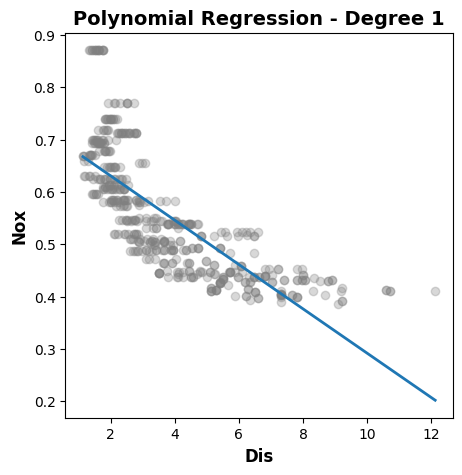

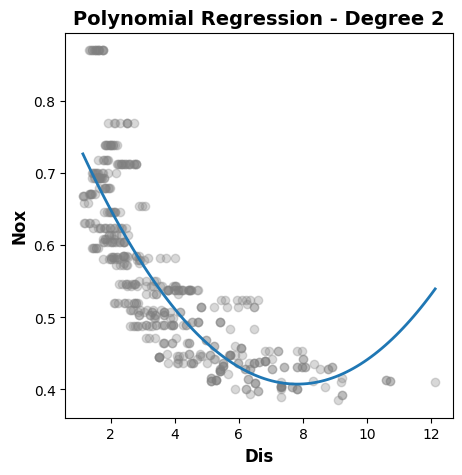

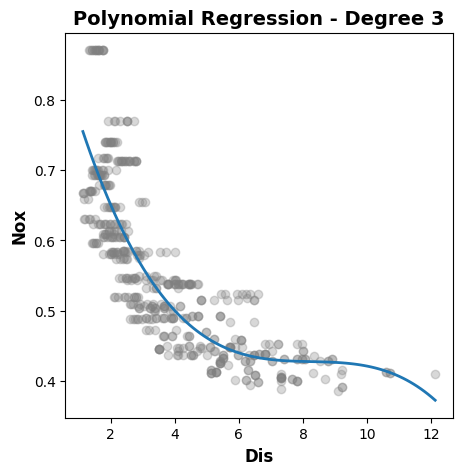

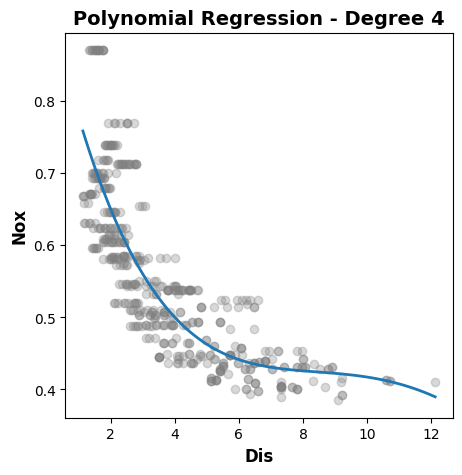

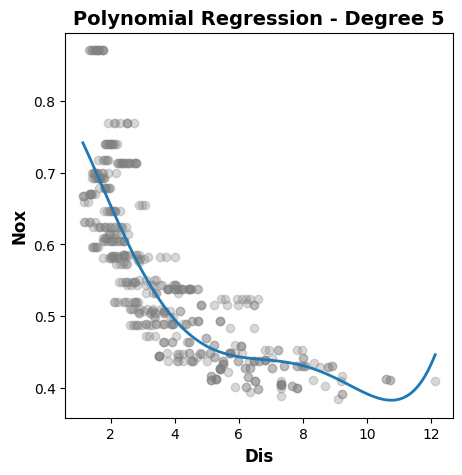

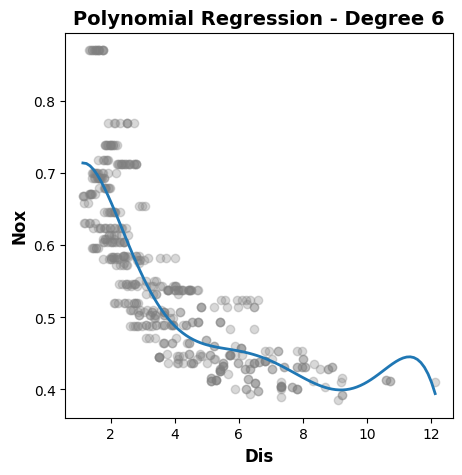

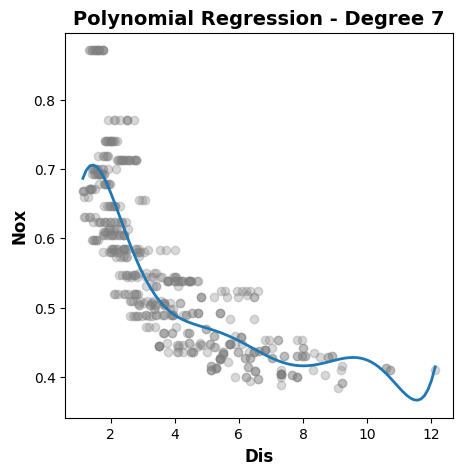

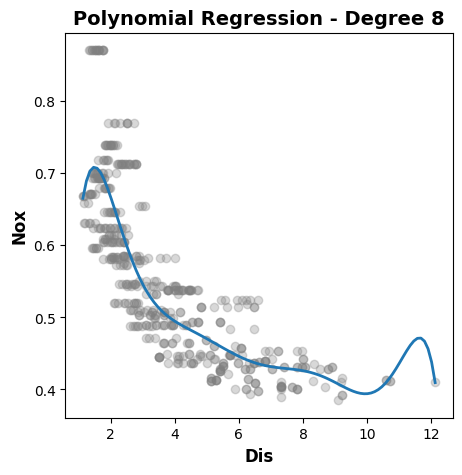

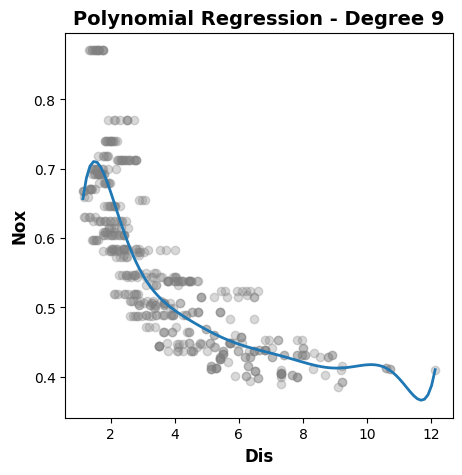

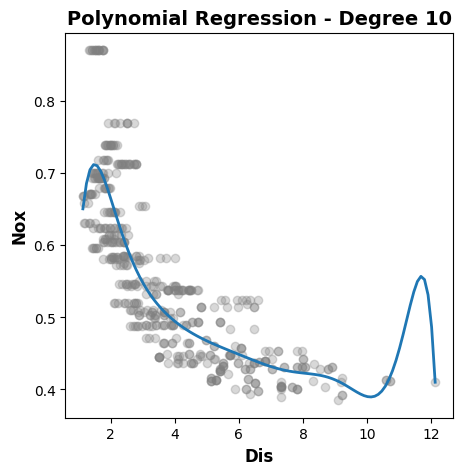

In [62]:
# Create a grid of data points (for completeness)
X_grid = np.linspace(boston['dis'].min(), boston['dis'].max(), 100)

# Loop through all polynomial models
for i in range(len(models_list)):

    # Adapt data_grid
    X_grid_poly = poly_regular(X_grid, i+1)

    # Predict
    y_hat = models_list[i].predict(X_grid_poly)

    # Create a figure & plot the data
    plt.figure(figsize=(5,5))
    plt.scatter(boston['dis'], boston['nox'], c='gray', alpha=0.3)
    
    # Plot the regression line
    plt.plot(X_grid, y_hat, linewidth=2, label=f'polynomial{i+1}');

    # Customize
    plt.title(f'Polynomial Regression - Degree {i+1}', **title_args)
    plt.xlabel('Dis', **label_args)
    plt.ylabel('Nox', **label_args)

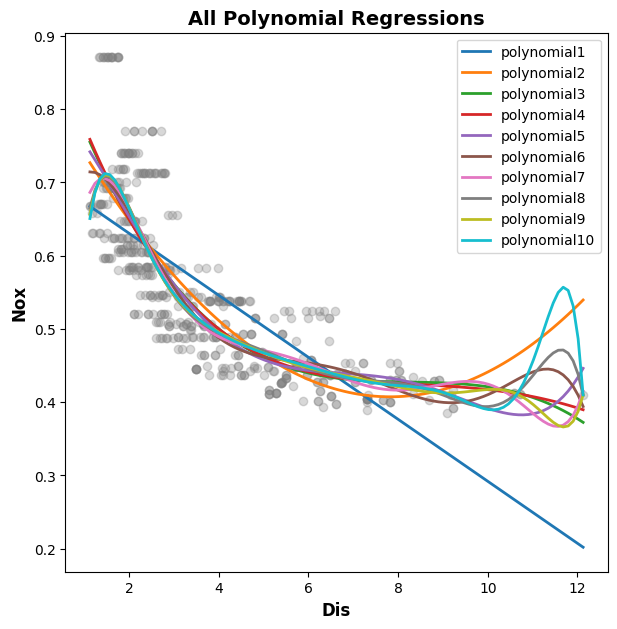

In [65]:
# Create a grid of data points (for completeness)
X_grid = np.linspace(boston['dis'].min(), boston['dis'].max(), 100)

# Create a figure & plot the data
plt.figure(figsize=(7,7))
plt.scatter(boston['dis'], boston['nox'], c='gray', alpha=0.3)

# Loop through all polynomial models
for i in range(len(models_list)):

    # Adapt data_grid
    X_grid_poly = poly_regular(X_grid, i+1)

    # Predict
    y_hat = models_list[i].predict(X_grid_poly)

    # Plot the regression line
    plt.plot(X_grid, y_hat, linewidth=2, label=f'polynomial{i+1}')

# Customize
plt.title('All Polynomial Regressions', **title_args)
plt.xlabel('Dis', **label_args)
plt.ylabel('Nox', **label_args)
plt.legend()
plt.show();

At higher polynomial orders, the model often shows an undesirable behavior, particularly at the boundaries of the data range. They tend to oscillate excessively near the edges of the data, which can lead to unrealistic predictions and poor generalization.

#### 9d)

### My initial thoughts

In a standard cubic spline, the degrees of freedom (df) used are computed by 4 + K, where K represents the number of knots. If we limit the model to only 4 degrees of freedom, the model simplifies to a single cubic polynomial that spans the entire data range without splits or knots.

Alternatively, one could decrease the complexity of the spline by using a quadratic spline that uses 3 + K degrees of freedom. This reduction makes it possible to include knot(s) to the model to achieve a total of 4 degrees of freedom.

In [66]:
from ISLP.models import (
summarize,
poly,
ModelSpec as MS
)
from ISLP.models import bs, ns

# Transform the dataset
bs = MS([bs('dis', df=4)])
Xbs = bs.fit_transform(boston)

# Create & fit the model
model = sm.OLS(nox, Xbs).fit()
summarize(model)

,coef,std err,t,P>|t|
intercept,0.7345,0.015,50.306,0.000
"bs(dis, df=4)[0]",-0.0581,0.022,-2.658,0.008
"bs(dis, df=4)[1]",-0.4636,0.024,-19.596,0.000
"bs(dis, df=4)[2]",-0.1998,0.043,-4.634,0.000
"bs(dis, df=4)[3]",-0.3888,0.046,-8.544,0.000


In [67]:
# Check the knots for df=4
BSpline(df=4, intercept=True).fit(dis).internal_knots_

array([], dtype=float64)

As initially expected, there aren't any knots when the cubic spline is restricted to only 4 degrees of freedom.

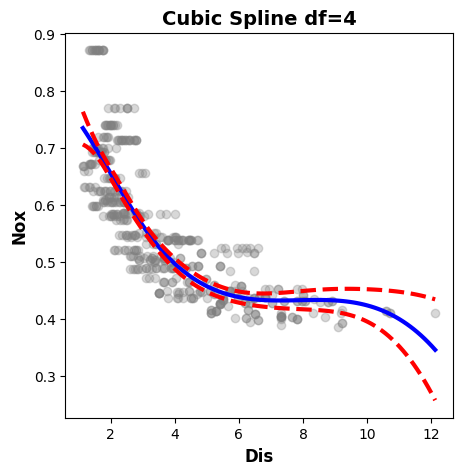

In [68]:
from ISLP.models import (
summarize,
poly,
ModelSpec as MS
)
from ISLP.models import bs, ns

# Transform the dataset
bs = MS([bs('dis', df=4)])
Xbs = bs.fit_transform(boston)

# Create & fit the model
model = sm.OLS(nox, Xbs).fit()

# Create a grid of data points (for completeness)
X_grid = np.linspace(boston['dis'].min(), boston['dis'].max(), 100)
X_grid_df = pd.DataFrame({'dis': X_grid})

# Transform the dataset
Xnew = bs.transform(X_grid_df)

# Predict & get CI
preds = model.get_prediction(Xnew)
preds_values = preds.predicted_mean
bands = preds.conf_int(alpha=0.05)

# Plot
fig, ax = plt.subplots(figsize=(5,5))
ax.scatter(dis, nox, c='gray', alpha=0.3)
ax.plot(X_grid, preds_values, 'b', linewidth=3)
ax.plot(X_grid, bands[:, 0], 'r--', linewidth=3)
ax.plot(X_grid, bands[:, 1], 'r--', linewidth=3)
ax.set_title('Cubic Spline df=4', **title_args)
ax.set_xlabel('Dis', **label_args)
ax.set_ylabel('Nox', **label_args);

#### 9e)

In [69]:
# Variables
k=5
n=21

# Initialize results dict
results_dict = {}

# Set up k-validation method
kfold = KFold(n_splits=k, shuffle=True, random_state=0)

# Loop through a range of degrees of freedom
for i in range(4, n):

    # Not importing the packages are causing errors
    from ISLP.models import (
    summarize,
    poly,
    ModelSpec as MS
    )
    from ISLP.models import bs, ns

    # Transform the dataset
    bs = MS([bs('dis', df=i)])
    Xbs = bs.fit_transform(boston)

    # Initialize a list of scores
    rss_list = []

    # Loop through cross-validation folds
    for train_idx, val_idx in kfold.split(Xbs):

        # Split the data
        X_train, X_val = Xbs.iloc[train_idx], Xbs.iloc[val_idx]
        y_train, y_val = boston['nox'].iloc[train_idx], boston['nox'].iloc[val_idx]

        # Create & fit a model
        model = sm.OLS(y_train, X_train).fit()

        # Predict
        y_hat = model.predict(X_val)
        rss = sum((y_val - y_hat)**2)

        # Update metric list
        rss_list.append(rss)

    # Compute cross-validation error
    rss_cv = np.mean(rss_list)

    # Update dict
    results_dict[i] = rss_cv

In [70]:
# Create a dataframe for the results
results = pd.DataFrame(results_dict.items(), columns=['DF', 'RSS-CV'])

# Show table
results.style.hide(axis='index')

DF,RSS-CV
4,0.389060
5,0.375250
6,0.373825
7,0.373309
8,0.373578
9,0.378799
10,0.374098
11,0.374257
12,0.372582
13,0.375057


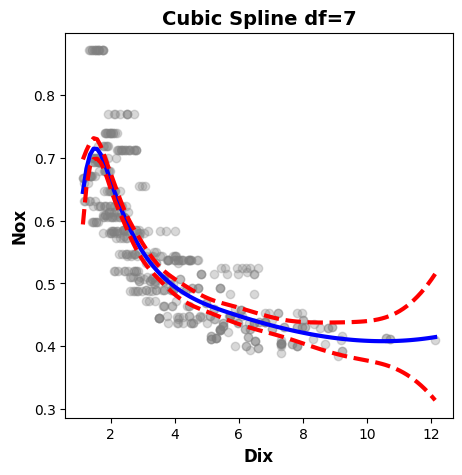

In [71]:
# Not importing the packages are causing errors
from ISLP.models import (
summarize,
poly,
ModelSpec as MS
)
from ISLP.models import bs, ns

# Transform the dataset
bs = MS([bs('dis', df=7)])
Xbs = bs.fit_transform(boston)

# Create a data grid
X_grid = np.linspace(boston['dis'].min(), boston['dis'].max(), 100)
X_grid_df = pd.DataFrame({'dis': X_grid})
X_grid_bs = bs.transform(X_grid_df)

# Create & fit a model
model = sm.OLS(boston['nox'], Xbs).fit()

# Predict & get CI
preds = model.get_prediction(X_grid_bs)
preds_values = preds.predicted_mean
bands = preds.conf_int(alpha=0.05)

# Plot
fig, ax = plt.subplots(figsize=(5,5))
ax.scatter(boston['dis'], boston['nox'], c='gray', alpha=0.3)
ax.plot(X_grid, preds_values, c='b', linewidth=3)
ax.plot(X_grid, bands[:, 0], c='r', ls='--', linewidth=3)
ax.plot(X_grid, bands[:, 1], c='r', ls='--', linewidth=3)

# Customize
ax.set_title('Cubic Spline df=7', **title_args)
ax.set_xlabel('Dix', **label_args)
ax.set_ylabel('Nox', **label_args);

When applying k-fold cross-validation across a range of degrees of freedom, the best model performance is achieved when the model is configured with df=7. This configuration results in the lowest Residual Sum of Squares (RSS) of 0.3733.

The plot above illustrates how the model with df=7 is more flexible when compared to the previous model with df=4, particularly at the lower range of 'Dix'. This increased flexibility allows the model to better adapt to the data, reducing the overall RSS.

#### 9f)

In [72]:
# Variables
k=5

# Initialize dict to hold results
results_dict = {}

# Set up k-validation method
kfold = KFold(n_splits=k, shuffle=True, random_state=0)

# Loop through a range of qcuts to create knots 
for i in range(1, 11):

    from ISLP.models import (
    summarize,
    poly,
    ModelSpec as MS
    )
    from ISLP.models import bs, ns
    
    # Split the data 
    cut_dis = pd.qcut(dis, i)

    # Get the categories
    cut_categories = cut_dis.cat.categories
    
    # Get the knots
    knots = cut_categories.right[:-1].to_list()

    # Transform the dataset
    bs = MS([bs('dis', internal_knots=knots)])
    Xbs = bs.fit_transform(boston)

    # Initialize list of scores
    rss_list = []

    # Loop through cross-validation folds
    for train_idx, val_idx in kfold.split(Xbs):
        # Split the data
        X_train, X_val = Xbs.iloc[train_idx], Xbs.iloc[val_idx]
        y_train, y_val = nox.iloc[train_idx], nox.iloc[val_idx]

        # Create and fit model
        model = sm.OLS(y_train, X_train).fit()

        # Predict on validation set
        y_hat = model.predict(X_val)
        rss = sum((y_val - y_hat)**2)

        # Update scores
        rss_list.append(rss)

    # Compute cross-validation score
    rss_cv = np.mean(rss_list)

    # Update dict
    results_dict[i] = rss_cv

In [73]:
# Create dataframe & present results
results_df = pd.DataFrame(results_dict.items(), columns=['Knots', 'RSS-CV'])
results_df.style.hide(axis='index')

Knots,RSS-CV
1,0.389227
2,0.389058
3,0.375250
4,0.373822
5,0.373309
6,0.373585
7,0.378786
8,0.374099
9,0.374264
10,0.372579


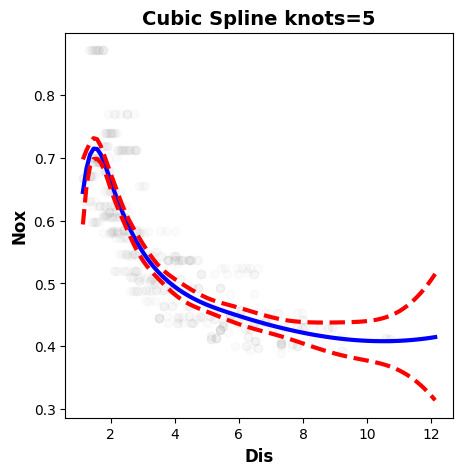

In [74]:
# Not importing the packages are causing errors
from ISLP.models import (
summarize,
poly,
ModelSpec as MS
)
from ISLP.models import bs, ns

# Split/cut the data
dis_cut = pd.qcut(boston['dis'], 5)

# Get the categories
categories = dis_cut.cat.categories

# Get the knots
knots = categories.right[:-1].to_list()

# Transform the dataset
bs = MS([bs('dis', internal_knots=knots)])
Xbs = bs.fit_transform(boston)

# Greate a data grid
X_grid = np.linspace(boston['dis'].min(), boston['dis'].max(), 100)
X_grid_df = pd.DataFrame({'dis': X_grid})
X_grid_bs = bs.transform(X_grid_df)

# Create & fit a model
model = sm.OLS(boston['nox'], Xbs).fit()

# Predict & get CI
preds = model.get_prediction(X_grid_bs)
preds_values = preds.predicted_mean
bands = preds.conf_int(alpha=0.05)

# Plot
fig, ax = plt.subplots(figsize=(5,5))
ax.scatter(boston['dis'], boston['nox'], c='gray', alpha=0.03)
ax.plot(X_grid, preds_values, c='b', linewidth=3)
ax.plot(X_grid, bands[:, 0], c='r', ls='--', linewidth=3)
ax.plot(X_grid, bands[:, 1], c='r', ls='--', linewidth=3)

# Customize
ax.set_title('Cubic Spline knots=5', **title_args)
ax.set_xlabel('Dis', **label_args)
ax.set_ylabel('Nox', **label_args);

When testing a range of knots using k-fold cross-validation, we observed that 5 knots provided the optimal balance of performance and complexity for our dataset. The knots were automatically determined based on sample quantiles, evenly distributed across the range of the feature values. While a model with 10 knots is also a viable option, it introduces additional complexity by increasing the number of parameters the model needs to estimate.

It is interesting to observe how employing degrees of freedom and knots lead to the same Residual Sum of Squares (RSS) and produces strikingly similar fits. This offers strong evidence supporting the chosen model.

---

### Question 10

#### 10a)

In [75]:
# Load dataset
college = pd.read_csv('data/College.csv')

# Rename columns
college.rename(columns={'Unnamed: 0': 'name'}, inplace=True)
college.columns = [x.lower() for x in college.columns]

# Add intercept
college.insert(0, 'intercept', np.ones(len(college)))

# Adapt 'private' data (dummy)
college['private'] = college['private'].apply(lambda x: 1 if x=='Yes' else 0)

# Remove 'name'
college.drop(columns='name', inplace=True)

In [76]:
# Create a function for forward stepwise feature selection
def forward_selection(X, y, k=5):
    # Split the dataset
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=0
    )
    
    # Set up k-fold cross-validation method
    kfold = KFold(n_splits=k, shuffle=True, random_state=0)
    
    # Get columns - current & remaining
    columns_current = ['intercept']
    columns_remaining = [col for col in X.columns if col != 'intercept']
    
    # Initialize validation metric
    mse_validation = []
    
    # Loop until all columns are tested
    while columns_remaining:
    
        # Initialize & track best MSE results
        mse_best = float('inf')
    
        # Loop through remaining columns
        for column in columns_remaining:
    
            # Create a dataframe
            X_ = X_train[columns_current + [column]]
    
            # Initialize metrics list
            mse_kfold = []
            
            # Loop through cross-validation folds
            for train_idx, val_idx in kfold.split(X_):
    
                # Split the dataset
                X_train_cv, X_val_cv = X_.iloc[train_idx], X_.iloc[val_idx]
                y_train_cv, y_val_cv = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
                # Create & fit the model
                model = sm.OLS(y_train_cv, X_train_cv).fit()
    
                # Predict & compute MSE
                y_hat = model.predict(X_val_cv)
                mse = sum((y_val_cv - y_hat)**2) / len(y_val_cv)
    
                # Update metris list
                mse_kfold.append(mse)
    
            # Get the cross-validation MSE
            mse_cv = np.mean(mse_kfold)
    
            # Check if it is the best MSE so far
            if mse_cv < mse_best:
                mse_best = mse_cv
                column_best = column
    
        # Create & fit a validation model
        model = sm.OLS(y_train, X_train[columns_current]).fit()
    
        # Predict & compute validation MSE
        y_hat = model.predict(X_test[columns_current])
        mse = sum((y_test - y_hat)**2) / len(y_hat)
    
        # Update validation MSE tracking list
        mse_validation.append(mse)
        
        # Update current best columns
        columns_current += [column_best]
    
        # Remove best column from columns remaining
        columns_remaining.remove(column_best)

    return columns_current, mse_validation

In [77]:
# Define exogenous & endogenous variables
X = college.drop(columns='outstate')
y = college['outstate']

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

# Test function
features, mse = forward_selection(X_train, y_train) 

# Create a dataframe for final results
results = pd.DataFrame(zip(features, mse), columns=['Feature', 'MSE-Validation'])
results.style.hide(axis='index')

Feature,MSE-Validation
intercept,16812740.062877
room.board,9710427.334317
perc.alumni,7029926.117600
expend,5624113.019651
private,4664606.165867
phd,4521365.319165
grad.rate,4386547.239912
terminal,4365789.184491
top10perc,4294507.303649
p.undergrad,4349515.202453


By applying k-fold cross-validation to guide forward stepwise feature selection, we observe that after including 'top10perc' there isn't any  improvement in the model's MSE. Therefore, we should limit the model to include all features up to 'top10perc' as listed in the table above.

Next, to ensure robustness of our findings and explore the potential impact of feature scaling, we will repeat the forward stepwise selection process after standardizing the dataset.

In [78]:
# Define exogenous & endogenous variables
X = college.drop(columns='outstate')
y = college['outstate']

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

# Initialize the scaler
scaler = StandardScaler()

# Fit & transform the data
X_train_st = scaler.fit_transform(X_train)
X_train_st = pd.DataFrame(X_train_st, columns=X_train.columns)

# Reset y_train index to match X_train_st
y_train.reset_index(drop=True, inplace=True)

# Implement forward feature selection
features, mse = forward_selection(X_train_st, y_train)

# Create a dataframe for final results
results_st = pd.DataFrame(zip(features, mse), columns=['Feature', 'MSE-Validation'])
results_st.style.hide(axis='index')

Feature,MSE-Validation
intercept,126728847.705479
expend,123960831.317824
private,123876004.578364
room.board,122855271.186713
grad.rate,121879234.108313
perc.alumni,121018773.106219
s.f.ratio,123072124.314685
personal,123259201.014724
top10perc,123107670.021144
top25perc,123106738.344287


Unfortunately, feature scaling did not provide improvement in model performance. This suggests that the model's performance is not constrained by issues related to feature scaling.

#### 10b), c), d)

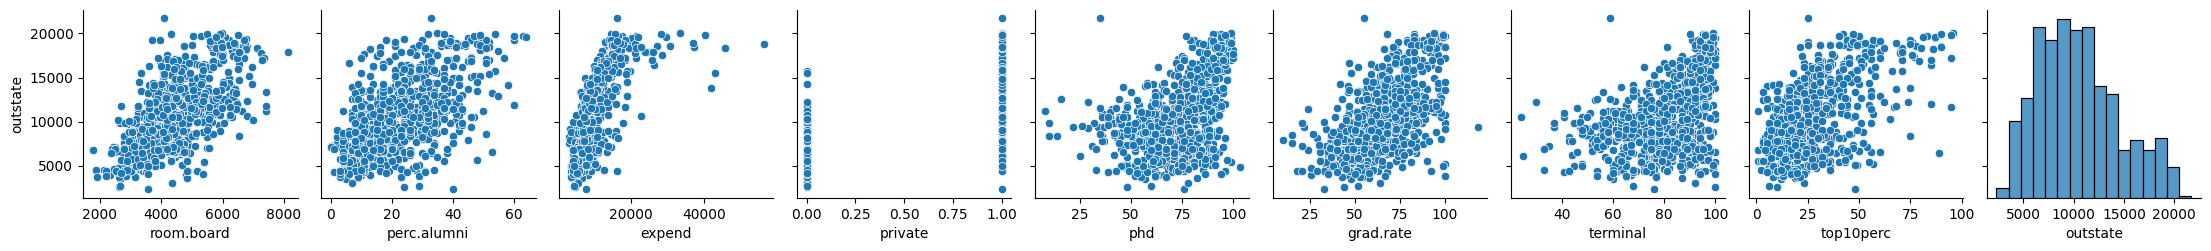

In [81]:
# Get the selected columns
columns_selected = results['Feature'][:np.argmin(results['MSE-Validation']) + 1].to_list()
columns_selected.remove('intercept')

# Show the last row
sns.pairplot(college[columns_selected + ['outstate']], y_vars='outstate');

The initial plot with the selected features against the exogenous variable does not give us a definitive conclusion. There is the possibility of a non-linear relationship between 'terminal' and 'outstate'.

Let's further explore non-linear patterns by modeling with GAMs.

In [82]:
# Define exogenous & endogenous variables
X = college.drop(columns='outstate')
y = college['outstate']

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

# Filter the data for selected features
X_train_selected, X_test_selected = X_train[columns_selected], X_test[columns_selected]

In [83]:
# Set up the GAM model
gam_selected = LinearGAM(
    s_gam(0) +
    s_gam(1) +
    s_gam(2) +
    f_gam(3, lam=0) +
    s_gam(4) +
    s_gam(5) +
    s_gam(6) +
    s_gam(7)
)

# Fit GAM model to train dataset
gam_selected = gam_selected.fit(X_train_selected, y_train)

# Predict on test dataset
y_hat = gam_selected.predict(X_test_selected)

# Compute MSE
gam_mse = sum((y_test - y_hat)**2) / len(y_test)

In [84]:
# Add intercetp to the datasets
X_train_selected.insert(0, 'intercept', np.ones(len(X_train_selected)))
X_test_selected.insert(0, 'intercept', np.ones(len(X_test_selected)))

# Create & fit a linear regression
model = sm.OLS(y_train, X_train_selected).fit()

# Predict on test dataset
y_hat = model.predict(X_test_selected)

# Compute MSE
linear_mse = sum((y_test - y_hat)**2) / len(y_test)

In [85]:
# Create a comparison table
results_table = pd.DataFrame(columns=['Model', 'MSE'])

# Update table
results_table.loc[len(results_table)] = 'Linear', round(linear_mse, 2)
results_table.loc[len(results_table)] = 'GAM', round(gam_mse, 2)

# Show table
results_table.style.format({'MSE': '{:,.2f}'}).hide(axis='index')

Model,MSE
Linear,"4,110,168.30"
GAM,"3,297,473.44"


The results table provides strong evidence that the dataset holds non-linear relationships. If the patterns were purely linear, we would not expect the linear regression with a significantly higher MSE value when compared to the GAM model.

The results table gives us a clear indicator that the dataset contain non-linear patterns, otherwise the linear regression wouldn't have had such higher MSE values when compared to the GAM model.

In [86]:
# Drop intercept from the dataset
X_train_selected = X_train_selected.iloc[:, 1:]
X_test_selected = X_test_selected.iloc[:, 1:]

In [87]:
X_train_selected.shape

(582, 8)

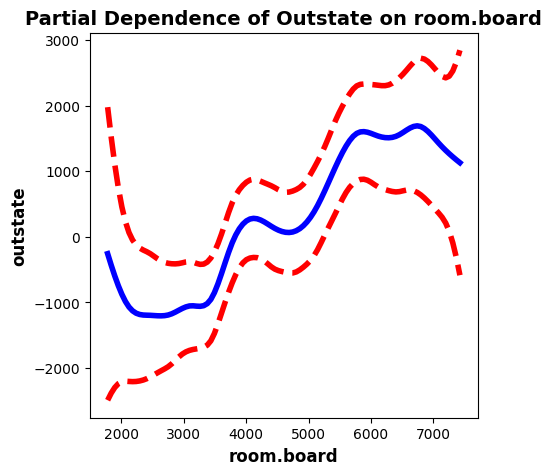

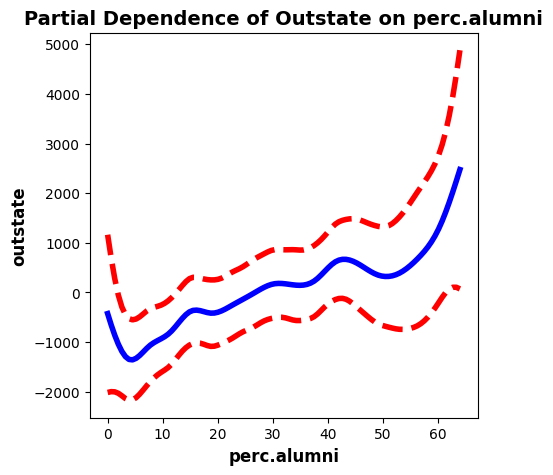

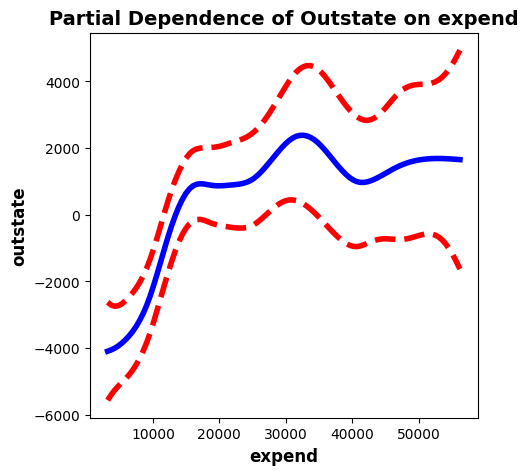

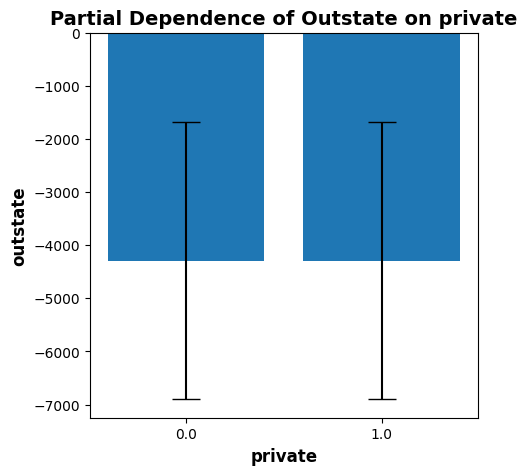

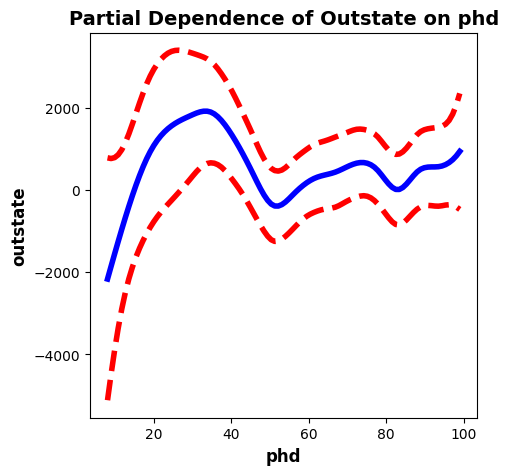

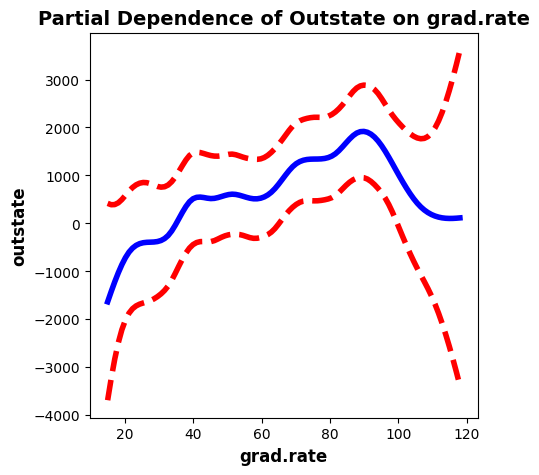

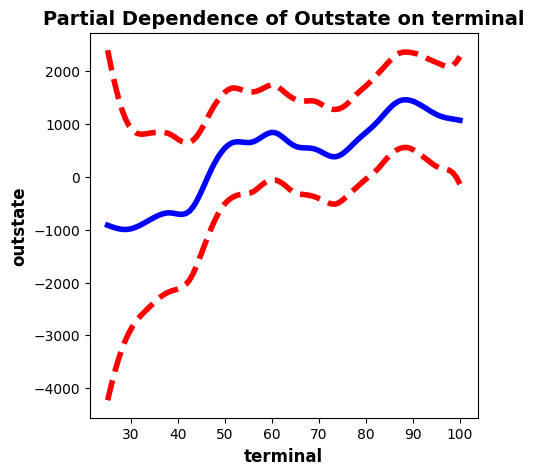

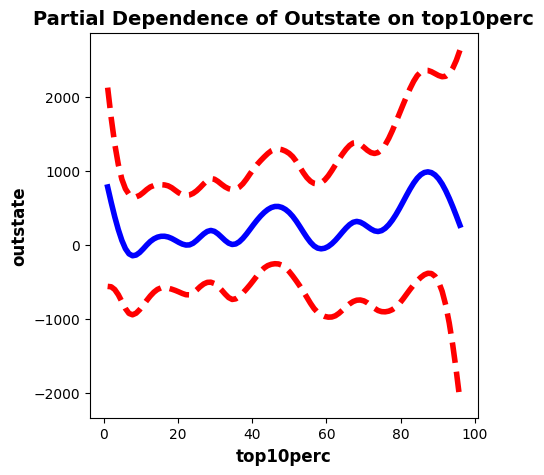

In [88]:
for i in range(X_train_selected.shape[1]):

    # Get column/feature name
    name = X_train_selected.columns[i]

    # Plot GAM partial effect    
    fig, ax = plt.subplots(figsize=(5,5))
    ax = plot_gam(gam_selected, i)

    #Customize
    ax.set_title(f'Partial Dependence of Outstate on {name}', **title_args)
    ax.set_xlabel(f'{name}', **label_args)
    ax.set_ylabel('outstate', **label_args)

The GAM partial dependence plots further validate our previous findings, confirming the presence of non-linear relationships within the dataset.

---

### Question 11

#### 11a)

In [89]:
# Set seed
np.random.seed(42)

# Set parameters
beta1 = 2
beta2 = 6

# Generate features
x1 = np.random.randn(100)
x2 = np.random.randn(100)
e = np.random.randn(100)

# Create a response y (endogenous variable)
y = 20 + beta1*x1 + beta2*x2 + e

#### 11b)

In [90]:
# Write a function to fit a linear regression
def simple_reg(outcome, feature):

    # Create a dataset with intercept
    X = np.column_stack((np.ones(len(feature)), feature))

    # Create & fit the model
    model = sm.OLS(outcome, X).fit()

    # Get parameters
    intercept = model.params[0]
    slope = model.params[1]

    return intercept, slope

#### 11c)

In [91]:
# Initialize beta1
beta1 = 100

#### 11d)

In [92]:
# Adapt the outcome
y_ = y - beta1*x1

# Estimate beta0 and beta2
beta0, beta2 = simple_reg(y_, x2)

#### 11e)

In [93]:
# Adapt the outcome
y_ = y - beta2*x2

# Estimate beta0 and beta1
beta0, beta1 = simple_reg(y_, x1)

#### 11f)

In [94]:
# Initialize beta1 again
beta1 = 100

# Initialize parameters lists
beta0_list, beta1_list, beta2_list = [], [], []

# Iterate 1,000 times
for i in range(1000):

    # Adapt the outcome
    y_ = y - beta1*x1
    
    # Estimate beta0 and beta2
    beta0, beta2 = simple_reg(y_, x2)

    # Adapt the outcome
    y_ = y - beta2*x2

    # Estimate beta0 and beta1
    beta0, beta1 = simple_reg(y_, x1)

    # Update lists
    beta0_list.append(beta0)
    beta1_list.append(beta1)
    beta2_list.append(beta2)

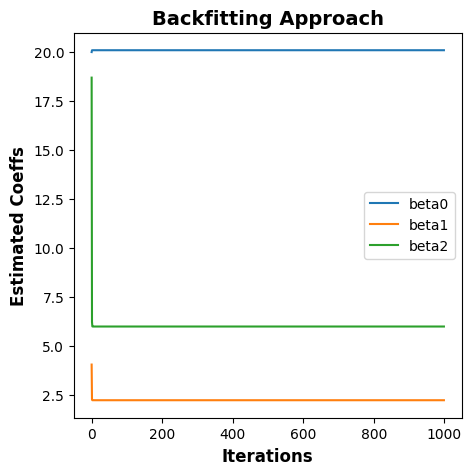

In [95]:
# Create a figure
plt.figure(figsize=(5,5))

# Plot parameters
plt.plot(range(1000), beta0_list, label='beta0')
plt.plot(range(1000), beta1_list, label='beta1')
plt.plot(range(1000), beta2_list, label='beta2')

# Customize
plt.title('Backfitting Approach', **title_args)
plt.xlabel('Iterations', **label_args)
plt.ylabel('Estimated Coeffs', **label_args)
plt.legend();

#### 11g)

In [96]:
# Create a dataset
X = np.column_stack((np.ones(len(x1)), x1, x2))

# Create & fit a model
model = sm.OLS(y, X).fit()

# Show model's parameters
model.params

array([20.08864867,  2.22608936,  5.98772322])

In [97]:
# Get the last values from previous method
beta0_list[-1], beta1_list[-1], beta2_list[-1]

(20.088648674649683, 2.2260893644210045, 5.987723223314731)

Both methods yield the same results for the coefficients.

#### 11h)

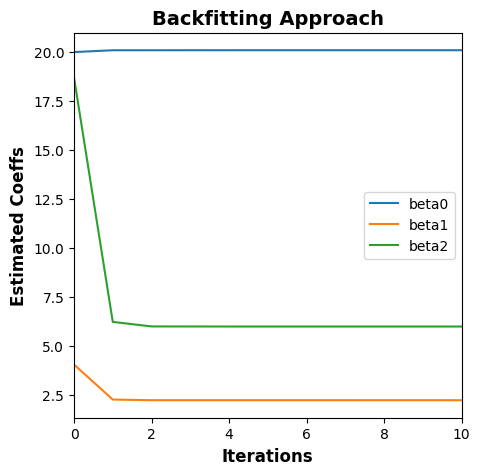

In [98]:
# Create a figure
plt.figure(figsize=(5,5))

# Plot parameters
plt.plot(range(1000), beta0_list, label='beta0')
plt.plot(range(1000), beta1_list, label='beta1')
plt.plot(range(1000), beta2_list, label='beta2')

# Customize
plt.title('Backfitting Approach', **title_args)
plt.xlabel('Iterations', **label_args)
plt.ylabel('Estimated Coeffs', **label_args)
plt.legend()
plt.xlim(0,10);

On this dataset, we were only required to do 1 iteration to get "good" approximation of the estimated coefficients.

---

### Question 12

In [99]:
# Set seed
np.random.seed(0)

# Number of samples (bigger due to bigger 'p')
n = 100

# Set beta0 or intercept
beta0 = 33

# Initialize response
y = beta0

# Initialize X
X = np.empty((n, 0))

# Loop through all coefs
for beta in range(2, 202, 2):

    # Generate data
    x_ = np.random.randn(n)

    # Check if X exists
    if X.size:
        # Stack feature column
        X = np.column_stack((X, x_*beta))
    else:
        # Create X
        X = x_

    # Add to the response
    y += beta*x_

# Generate error
e = np.random.randn(n)

# Update response
y += e

In [100]:
# Initialize params dict
params_dict = {'intercept': []}
for i in range(1, 101):
    params_dict[f'beta{i}'] = []

# Initialize betas
betas = np.ones(100) * 33

# Choose number of iterations
n = 100

# Start iterations
for iteration in range(n):
    
    # Store updated betas
    new_betas = betas.copy()
    
    # Loop through features
    for i in range(X.shape[1]):
    
        # Get feature
        x_i = X[:, i]
    
        # Remove feature from dataset & betas
        X_ = np.delete(X, i, axis=1)
        betas_ = np.delete(betas, i)
    
        # Adapt response
        y_ = y - np.matmul(X_, betas_)
    
        # Create & fit a model
        intercept, slope = simple_reg(y_, x_i)
    
        # Update betas
        new_betas[i] = slope
    
        # Update params_dict
        params_dict[f'beta{i + 1}'].append(slope)
    
    # Update intercept (once per iteration)
    params_dict['intercept'].append(intercept)

    # Assign new betas to betas for next iteration
    betas = new_betas.copy()

In [101]:
# Create a dataframe for the parameters
params_df = pd.DataFrame(params_dict)

# Look at the initial observations
params_df.head()

,intercept,beta1,beta2,beta3,beta4,beta5,beta6,beta7,beta8,beta9,...,beta91,beta92,beta93,beta94,beta95,beta96,beta97,beta98,beta99,beta100
0,7453.727579,2097.014769,-2622.059269,-111.873202,235.027465,-58.701600,263.304357,-172.315344,-427.116184,265.680362,...,10.454089,-24.667156,18.064704,-15.034897,40.148362,-38.052508,3.390359,8.651371,3.745739,-15.216395
1,-7075.587335,5233.961076,2017.757703,138.836469,-866.444864,-496.195118,-1126.814983,-97.260539,889.450896,-267.083979,...,37.952754,87.943469,15.371068,92.470868,-36.540209,73.612533,15.419581,36.377031,64.334786,80.292591
2,17222.697525,-14708.010715,-7704.920710,739.956434,2580.208087,1054.495406,2500.514923,-97.439516,-1845.198403,817.954975,...,-17.540950,-157.798347,11.897666,-127.924481,154.705683,-147.712519,2.066690,-31.151247,-81.036781,-120.425066
3,-32349.183447,52198.568475,16471.092856,-2955.101165,-6447.529306,-3769.630219,-6818.026458,-585.099784,4213.745167,-1278.489849,...,86.329378,400.710436,57.631319,355.665421,-323.463704,336.840136,38.116536,124.290641,253.115533,307.692459
4,77467.770674,-145980.042408,-46771.666334,11312.109605,15552.970676,10792.144368,16895.908917,1703.181237,-9392.466262,2605.550892,...,-152.239933,-911.968246,-134.207540,-719.322732,853.235905,-767.679381,-63.092333,-244.599856,-552.078823,-619.762696


In [102]:
# Look at the final observations
params_df.tail()

,intercept,beta1,beta2,beta3,beta4,beta5,beta6,beta7,beta8,beta9,...,beta91,beta92,beta93,beta94,beta95,beta96,beta97,beta98,beta99,beta100
95,-6.216848e+44,1.536720e+45,6.904023e+44,-2.727942e+44,4.454143e+43,-2.551879e+44,-1.274459e+44,-1.306060e+44,-1.791240e+43,5.122016e+43,...,5.983775e+42,4.443272e+42,-8.987963e+41,-2.614533e+42,-4.433447e+42,4.623542e+42,-3.940982e+42,6.059659e+41,7.237017e+42,1.540742e+41
96,1.722582e+45,-4.257978e+45,-1.912986e+45,7.558652e+44,-1.234183e+44,7.070823e+44,3.531298e+44,3.618881e+44,4.963317e+43,-1.419225e+44,...,-1.658005e+43,-1.231151e+43,2.490440e+42,7.244521e+42,1.228426e+43,-1.281100e+43,1.091983e+43,-1.679016e+42,-2.005254e+43,-4.268883e+41
97,-4.772981e+45,1.179810e+46,5.300556e+45,-2.094371e+45,3.419749e+44,-1.959205e+45,-9.784601e+44,-1.002733e+45,-1.375274e+44,3.932436e+44,...,4.594059e+43,3.411298e+43,-6.900656e+42,-2.007357e+43,-3.403742e+43,3.549697e+43,-3.025711e+43,4.652236e+42,5.556217e+43,1.182773e+42
98,1.322511e+46,-3.269046e+46,-1.468693e+46,5.803140e+45,-9.475636e+44,5.428623e+45,2.711140e+45,2.778407e+45,3.810708e+44,-1.089612e+45,...,-1.272938e+44,-9.452101e+43,1.912072e+43,5.562102e+43,9.431150e+43,-9.835574e+43,8.383755e+43,-1.289048e+43,-1.539533e+44,-3.277111e+42
99,-3.664454e+46,9.057953e+46,4.069498e+46,-1.607950e+46,2.625561e+45,-1.504179e+46,-7.512093e+45,-7.698507e+45,-1.055897e+45,3.019132e+45,...,3.527098e+44,2.619010e+44,-5.298068e+43,-1.541178e+44,-2.613201e+44,2.725263e+44,-2.323002e+44,3.571713e+43,4.265784e+44,9.079945e+42


After running 100 iterations of the backfitting method, we observe the parameter estimates have not fully converged. This suggests that the model is struggling to stabilize, possibly due to the high-dimensional naure of the dataset.

Initially, when we had only two parameters, convergence was achievable. However, as we increased the number of parameters from 2 to 100, the complexity of the model grew significantly.

One possible explanation for this issue is the **curse of dimensionality**, requiring more data to properly estimate the relationship between features and the response variable.

In [103]:
# Set seed
np.random.seed(0)

# Number of samples (bigger due to bigger 'p')
n = 1_000

# Set beta0 or intercept
beta0 = 33

# Initialize response
y = beta0

# Initialize X
X = np.empty((n, 0))

# Loop through all coefs
for beta in range(2, 202, 2):

    # Generate data
    x_ = np.random.randn(n)

    # Check if X exists
    if X.size:
        # Stack feature column
        X = np.column_stack((X, x_*beta))
    else:
        # Create X
        X = x_

    # Add to the response
    y += beta*x_

# Generate error
e = np.random.randn(n)

# Update response
y += e

In [104]:
# Initialize params dict
params_dict = {'intercept': []}
for i in range(1, 101):
    params_dict[f'beta{i}'] = []

# Initialize betas
betas = np.ones(100) * 33

# Choose number of iterations
n = 100

# Start iterations
for iteration in range(n):
    
    # Store updated betas
    new_betas = betas.copy()
    
    # Loop through features
    for i in range(X.shape[1]):
    
        # Get feature
        x_i = X[:, i]
    
        # Remove feature from dataset & betas
        X_ = np.delete(X, i, axis=1)
        betas_ = np.delete(betas, i)
    
        # Adapt response
        y_ = y - np.matmul(X_, betas_)
    
        # Create & fit a model
        intercept, slope = simple_reg(y_, x_i)
    
        # Update betas
        new_betas[i] = slope
    
        # Update params_dict
        params_dict[f'beta{i + 1}'].append(slope)
    
    # Update intercept (once per iteration)
    params_dict['intercept'].append(intercept)

    # Assign new betas to betas for next iteration
    betas = new_betas.copy()

In [105]:
# Create a dataframe for the parameters
params_df = pd.DataFrame(params_dict)

# Look at the initial observations
params_df.head()

,intercept,beta1,beta2,beta3,beta4,beta5,beta6,beta7,beta8,beta9,...,beta91,beta92,beta93,beta94,beta95,beta96,beta97,beta98,beta99,beta100
0,-1477.486964,-105.038259,-39.376144,-117.405643,9.752342,-9.041084,-115.190998,-62.676277,79.126558,-88.201000,...,8.456416,6.433830,-7.993789,-5.034613,6.785893,-0.019075,4.850962,5.026650,-2.179709,-11.087491
1,182.855981,331.067977,92.975241,25.333253,-39.955398,45.029004,50.323302,-25.933433,49.878171,14.513530,...,1.523961,4.788713,1.230665,6.868143,1.170922,6.999650,6.052694,4.708938,2.716763,5.008434
2,-154.557747,5.266786,-48.416042,-17.507907,12.907491,1.660855,-42.351974,-15.207187,9.806649,-11.611815,...,1.679583,1.647072,-0.489674,-1.913745,2.117361,-0.750384,1.658175,1.417917,0.280201,-2.682785
3,104.973086,52.959317,31.959042,8.695966,-14.685487,16.885804,21.674524,-2.548474,11.847036,5.870367,...,0.957171,2.095917,0.989091,3.164299,0.601282,2.666840,2.087861,2.100516,1.185843,2.439863
4,-22.678426,19.780768,-20.001906,-5.308390,7.365961,-2.345637,-14.492546,-3.259672,2.322254,-1.977968,...,1.082589,0.899169,0.701700,-0.279327,1.396757,0.172539,1.006516,0.857278,0.785524,-0.205102


In [106]:
# Look at the final observations
params_df.tail()

,intercept,beta1,beta2,beta3,beta4,beta5,beta6,beta7,beta8,beta9,...,beta91,beta92,beta93,beta94,beta95,beta96,beta97,beta98,beta99,beta100
95,33.041682,1.975387,1.013673,0.997209,0.996702,0.999832,1.002992,0.997448,0.99891,1.000401,...,0.99988,0.999907,0.999851,1.000029,0.999798,1.00008,0.999864,0.999779,0.999985,0.999895
96,33.041682,1.975387,1.013673,0.997209,0.996702,0.999832,1.002992,0.997448,0.99891,1.000401,...,0.99988,0.999907,0.999851,1.000029,0.999798,1.00008,0.999864,0.999779,0.999985,0.999895
97,33.041682,1.975387,1.013673,0.997209,0.996702,0.999832,1.002992,0.997448,0.99891,1.000401,...,0.99988,0.999907,0.999851,1.000029,0.999798,1.00008,0.999864,0.999779,0.999985,0.999895
98,33.041682,1.975387,1.013673,0.997209,0.996702,0.999832,1.002992,0.997448,0.99891,1.000401,...,0.99988,0.999907,0.999851,1.000029,0.999798,1.00008,0.999864,0.999779,0.999985,0.999895
99,33.041682,1.975387,1.013673,0.997209,0.996702,0.999832,1.002992,0.997448,0.99891,1.000401,...,0.99988,0.999907,0.999851,1.000029,0.999798,1.00008,0.999864,0.999779,0.999985,0.999895


When analyzing the first few iterations of the backfitting process, we do not observe immediate convergence in the parameter estimates. However, by the end of 100 iterations, some parameters ('intercept' and 'beta1') show signs of stabilization. Aside from the first two coefficients, the others do not provide reliable estimates.

One potential reason for this behavior is **multicollinearity**, which occurs when predictor variables in a dataset are highly correlated with one another. If one predictor can be approximately reconstructed from a combination of others, the model cannot accurately determine each variable's unique contribution to the response variable.

In [107]:
# Add intercetp to dataset
X_ = np.insert(X, 0, np.ones(len(X)), axis=1)

# Create & fit a linear regression model
model = sm.OLS(y, X_).fit()

# Show the first 10 params
model.params[:10]

array([33.0416822 ,  1.97538729,  1.01367296,  0.99720932,  0.99670222,
        0.99983198,  1.00299204,  0.99744801,  0.99890954,  1.00040108])

Our analysis reveals that the **backfitting approach** converges to the same parameter estimates as the **linear regression model**. This indicates that the iterative backfitting process is functioning as expected and reaching a stable solution. However, both methods struggle to accurately estimate the true parameter values from the data.